<a href="https://colab.research.google.com/github/haliait/sys_retinopathie_diabetique/blob/main/DR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"halimaaithamou","key":"5506a13175de3fcc7119707f4920953b"}'}

In [2]:
!ls

kaggle.json  sample_data


In [3]:
!mkdir -p ~/.kaggle
!cp "kaggle.json" ~/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json

In [4]:
!kaggle datasets list

ref                                                                     title                                                     size  lastUpdated                 downloadCount  voteCount  usabilityRating  
----------------------------------------------------------------------  --------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
laveshjadon/ai-impact-on-students                                       Impact of Ai on Students                               1187170  2026-05-10 23:12:10.070000           5489        141                1  
muhammadwaqas023/ai-impact-in-future-on-jobs-market-in-2030             Ai Impact in future on jobs market in 2030              108338  2026-05-24 15:12:54.047000           1602         39                1  
divyjain28/superstore-sales                                             Superstore Sales Analysis                              1579499  2026-05-15 08:16:38.500000      

In [5]:
!kaggle datasets download -d mariaherrerot/aptos2019

Dataset URL: https://www.kaggle.com/datasets/mariaherrerot/aptos2019
License(s): unknown
100% 8.01G/8.01G [00:53<00:00, 161MB/s]



In [6]:
!ls

aptos2019.zip  kaggle.json  sample_data


In [7]:
!unzip aptos2019.zip

Archive:  aptos2019.zip
  inflating: test.csv                
  inflating: test_images/test_images/e4dcca36ceb4.png  
  inflating: test_images/test_images/e4e343eaae2a.png  
  inflating: test_images/test_images/e4f12411fd85.png  
  inflating: test_images/test_images/e50b0174690d.png  
  inflating: test_images/test_images/e5197d77ec68.png  
  inflating: test_images/test_images/e529c5757d64.png  
  inflating: test_images/test_images/e52ed5c29c5e.png  
  inflating: test_images/test_images/e540d2e35d15.png  
  inflating: test_images/test_images/e55188915f9d.png  
  inflating: test_images/test_images/e580676516b0.png  
  inflating: test_images/test_images/e582e56e7942.png  
  inflating: test_images/test_images/e594c19e2e1d.png  
  inflating: test_images/test_images/e599151ca14b.png  
  inflating: test_images/test_images/e59c5f345bb0.png  
  inflating: test_images/test_images/e5d56f4f359b.png  
  inflating: test_images/test_images/e5de79795c1d.png  
  inflating: test_images/test_images/e5f33

In [8]:
!ls

aptos2019.zip  sample_data  test_images  train_images  val_images
kaggle.json    test.csv     train_1.csv  valid.csv


In [9]:
!git clone https://github.com/haliait/sys_retinopathie_diabetique

Cloning into 'sys_retinopathie_diabetique'...
remote: Enumerating objects: 38, done.
remote: Counting objects: 100% (38/38), done.
remote: Compressing objects: 100% (36/36), done.
remote: Total 38 (delta 18), reused 3 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (38/38), 10.41 MiB | 28.27 MiB/s, done.
Resolving deltas: 100% (18/18), done.


In [10]:
%cd sys_retinopathie_diabetique

/content/sys_retinopathie_diabetique


In [11]:
!ls

DR.ipynb		    eda_images_par_classe.png  phase-2.ipynb
eda_class_distribution.png  phase-1.ipynb	       README.md


In [12]:
!git pull origin main

From https://github.com/haliait/sys_retinopathie_diabetique
 * branch            main       -> FETCH_HEAD
Already up to date.


In [13]:
!git config --global user.name "haliait"
!git config --global user.email "halima.aithamou1510@gmail.com"

# Phase 1 : Exploration des données (EDA)

# Imports & configuration

In [14]:
import kagglehub
path = kagglehub.dataset_download("mariaherrerot/aptos2019")

Using Colab cache for faster access to the 'aptos2019' dataset.


In [15]:
print(path)

/kaggle/input/aptos2019


In [16]:
import os
os.listdir(path)

['val_images',
 'train_images',
 'valid.csv',
 'test.csv',
 'train_1.csv',
 'test_images']

In [17]:
# ============================================================
# SECTION 1 — EXPLORATION DES DONNÉES (EDA)
# Projet PFA : Détection intelligente de la rétinopathie diabétique
# Dataset   : APTOS 2019 Blindness Detection
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import cv2
import os
from PIL import Image
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Reproductibilité — obligatoire pour un projet académique
np.random.seed(42)

# ── Chemins Kaggle ──────────────────────────────────────────
# Vérifier d'abord avec : os.listdir('/kaggle/input/')
BASE_PATH = path         # adapter si besoin
TRAIN_CSV  = os.path.join(BASE_PATH, 'train_1.csv')
TEST_CSV   = os.path.join(BASE_PATH, 'test.csv')
TRAIN_DIR  = os.path.join(BASE_PATH, 'train_images', 'train_images')
TEST_DIR   = os.path.join(BASE_PATH, 'test_images',  'test_images')

# ── Nommage clinique des classes ─────────────────────────────
CLASS_NAMES = {
    0: 'No DR',
    1: 'Mild DR',
    2: 'Moderate DR',
    3: 'Severe DR',
    4: 'Proliferative DR'
}
COLORS = ['#27ae60', '#f39c12', '#e67e22', '#c0392b', '#8e44ad']

# Chargement et audit basique

In [18]:
df_train = pd.read_csv(TRAIN_CSV)
df_test  = pd.read_csv(TEST_CSV)

print("╔══════════════════════════════════════╗")
print("║     AUDIT DU DATASET APTOS 2019      ║")
print("╚══════════════════════════════════════╝\n")

print(f"  Lignes train     : {len(df_train)}")
print(f"  Lignes test      : {len(df_test)}")
print(f"  Colonnes train   : {list(df_train.columns)}")
print(f"  Valeurs manquan. : {df_train.isnull().sum().to_dict()}")
print(f"  Doublons         : {df_train.duplicated().sum()}")
print(f"\nAperçu :")
display(df_train.head(8))

print(f"\nRépartition par classe :")
for label, count in df_train['diagnosis'].value_counts().sort_index().items():
    pct = count / len(df_train) * 100
    bar = '█' * int(pct / 2)
    print(f"  Classe {label} ({CLASS_NAMES[label]:18s}) : {count:4d}  {bar} {pct:.1f}%")

╔══════════════════════════════════════╗
║     AUDIT DU DATASET APTOS 2019      ║
╚══════════════════════════════════════╝

  Lignes train     : 2930
  Lignes test      : 366
  Colonnes train   : ['id_code', 'diagnosis']
  Valeurs manquan. : {'id_code': 0, 'diagnosis': 0}
  Doublons         : 0

Aperçu :


,id_code,diagnosis
0,1ae8c165fd53,2
1,1b329a127307,1
2,1b32e1d775ea,4
3,1b3647865779,0
4,1b398c0494d1,0
5,1b4625877527,2
6,1b495ac025b7,3
7,1b862fb6f65d,0



Répartition par classe :
  Classe 0 (No DR             ) : 1434  ████████████████████████ 48.9%
  Classe 1 (Mild DR           ) :  300  █████ 10.2%
  Classe 2 (Moderate DR       ) :  808  █████████████ 27.6%
  Classe 3 (Severe DR         ) :  154  ██ 5.3%
  Classe 4 (Proliferative DR  ) :  234  ███ 8.0%


# Visualisation de la distribution des classes

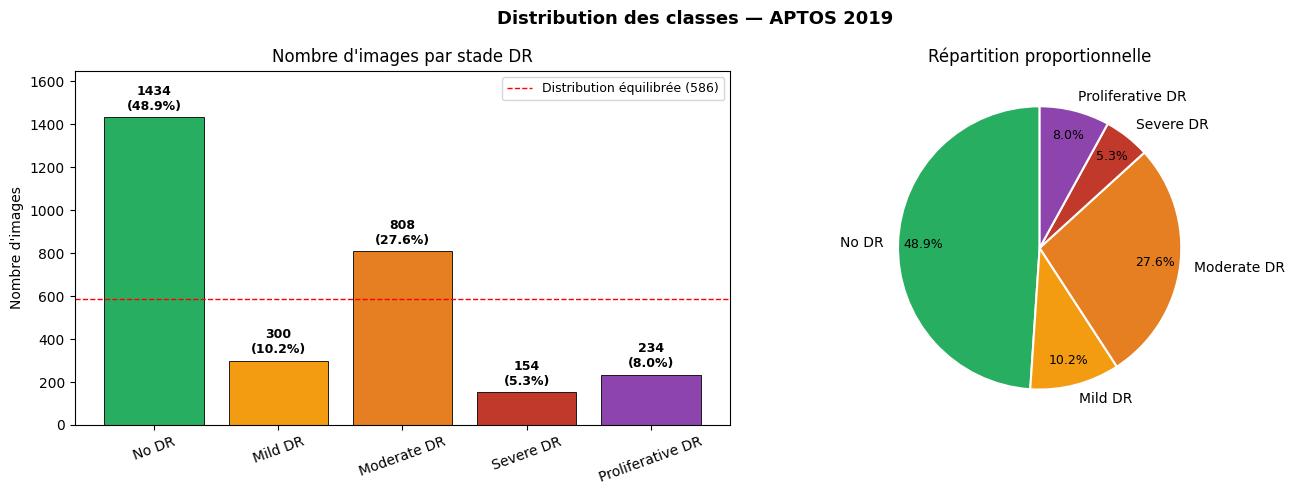


=== ANALYSE DU DÉSÉQUILIBRE DE CLASSES ===
  Classe 0 (No DR             ) : ratio   1.0x ✓
  Classe 1 (Mild DR           ) : ratio   4.8x ⚠️  minoritaire
  Classe 2 (Moderate DR       ) : ratio   1.8x ✓
  Classe 3 (Severe DR         ) : ratio   9.3x ⚠️  minoritaire
  Classe 4 (Proliferative DR  ) : ratio   6.1x ⚠️  minoritaire


In [19]:
class_counts = df_train['diagnosis'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribution des classes — APTOS 2019', fontsize=13, fontweight='bold')

# ── Barplot avec annotations ─────────────────────────────────
bars = axes[0].bar(
    [CLASS_NAMES[i] for i in class_counts.index],
    class_counts.values,
    color=COLORS, edgecolor='black', linewidth=0.6
)
axes[0].set_title('Nombre d\'images par stade DR')
axes[0].set_ylabel('Nombre d\'images')
axes[0].tick_params(axis='x', rotation=20)
axes[0].set_ylim(0, class_counts.max() * 1.15)

for bar, val in zip(bars, class_counts.values):
    pct = val / len(df_train) * 100
    axes[0].text(
        bar.get_x() + bar.get_width() / 2., bar.get_height() + 20,
        f'{val}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=9, fontweight='bold'
    )

# Ligne de référence : distribution équilibrée idéale
balanced = len(df_train) / 5
axes[0].axhline(balanced, color='red', linestyle='--', linewidth=1, label=f'Distribution équilibrée ({int(balanced)})')
axes[0].legend(fontsize=9)

# ── Pie chart ────────────────────────────────────────────────
wedges, texts, autotexts = axes[1].pie(
    class_counts.values,
    labels=[CLASS_NAMES[i] for i in class_counts.index],
    autopct='%1.1f%%', colors=COLORS,
    startangle=90, pctdistance=0.82,
    wedgeprops=dict(edgecolor='white', linewidth=1.5)
)
for at in autotexts:
    at.set_fontsize(9)
axes[1].set_title('Répartition proportionnelle')

plt.tight_layout()
plt.savefig('eda_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Quantification du déséquilibre ──────────────────────────
print("\n=== ANALYSE DU DÉSÉQUILIBRE DE CLASSES ===")
majority = class_counts.max()
for label, count in class_counts.items():
    ratio = majority / count
    status = "⚠️  minoritaire" if ratio > 3 else "✓"
    print(f"  Classe {label} ({CLASS_NAMES[label]:18s}) : ratio {ratio:5.1f}x {status}")

# Visualisation des images par classe

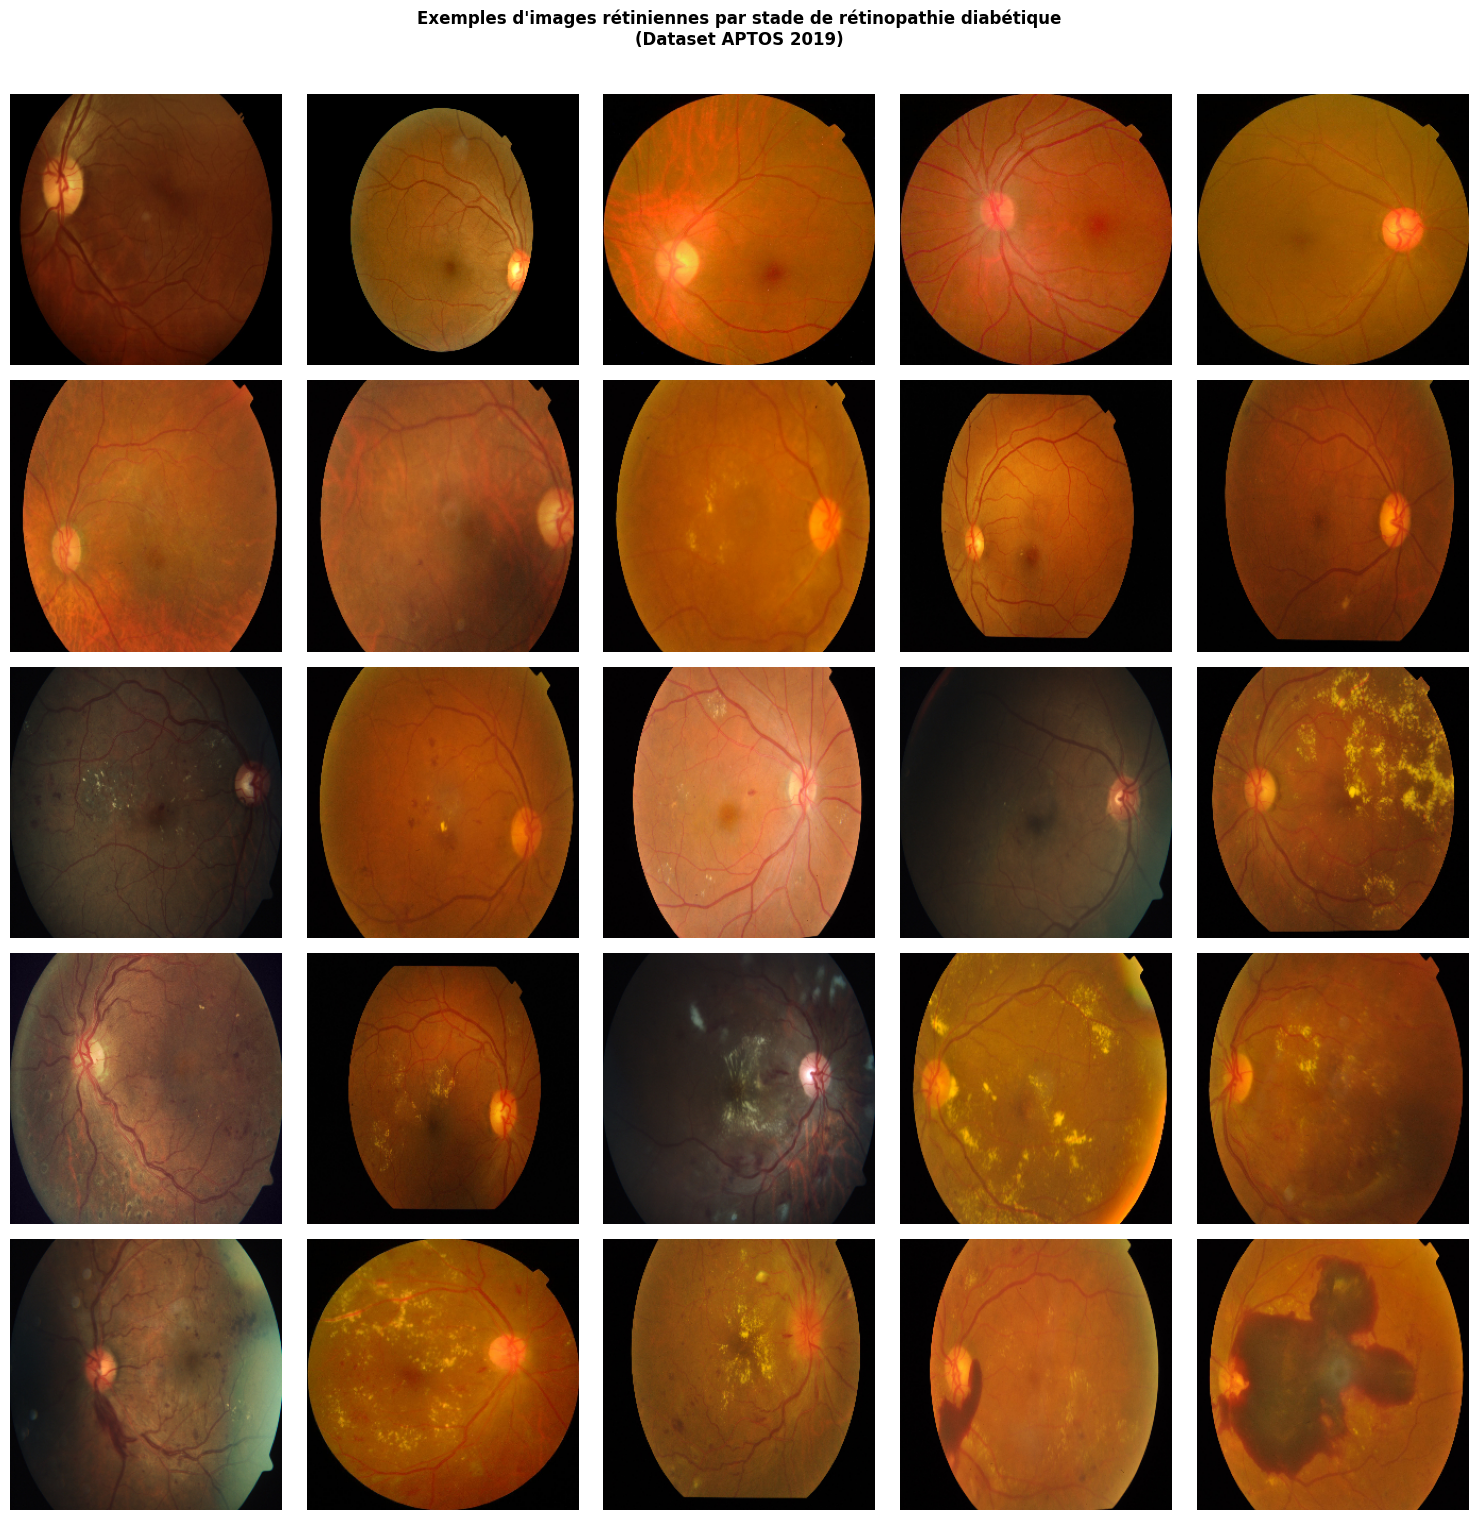

In [20]:
def load_image(img_id, directory, size=(256, 256)):
    """Charge une image en RGB avec fallback png/jpeg."""
    for ext in ['.png', '.jpeg', '.jpg']:
        path = os.path.join(directory, img_id + ext)
        if os.path.exists(path):
            img = cv2.imread(path)
            if img is not None:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                return cv2.resize(img, size)
    return None

N_SAMPLES = 5  # images par classe

fig, axes = plt.subplots(5, N_SAMPLES, figsize=(N_SAMPLES * 3, 5 * 3))
fig.suptitle('Exemples d\'images rétiniennes par stade de rétinopathie diabétique\n(Dataset APTOS 2019)',
             fontsize=12, fontweight='bold', y=1.01)

for label in range(5):
    samples = df_train[df_train['diagnosis'] == label].sample(N_SAMPLES, random_state=42)
    for j, (_, row) in enumerate(samples.iterrows()):
        img = load_image(row['id_code'], TRAIN_DIR)
        if img is not None:
            axes[label][j].imshow(img)
        axes[label][j].axis('off')
        if j == 0:
            axes[label][j].set_ylabel(
                f"Classe {label}\n{CLASS_NAMES[label]}",
                fontsize=10, fontweight='bold',
                rotation=0, labelpad=90, va='center',
                color=COLORS[label]
            )

plt.tight_layout()
plt.savefig('eda_images_par_classe.png', dpi=150, bbox_inches='tight')
plt.show()

In [21]:
!git clone https://github.com/haliait/sys_retinopathie_diabetique

Cloning into 'sys_retinopathie_diabetique'...
remote: Enumerating objects: 38, done.
remote: Counting objects: 100% (38/38), done.
remote: Compressing objects: 100% (36/36), done.
remote: Total 38 (delta 18), reused 3 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (38/38), 10.41 MiB | 32.50 MiB/s, done.
Resolving deltas: 100% (18/18), done.


In [22]:
%cd sys_retinopathie_diabetique

/content/sys_retinopathie_diabetique/sys_retinopathie_diabetique


In [23]:
!git add .
!git commit -m "init phase 1"

On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean


In [24]:
!git remote -v

origin	https://github.com/haliait/sys_retinopathie_diabetique (fetch)
origin	https://github.com/haliait/sys_retinopathie_diabetique (push)


In [25]:
!git config --global user.name "haliait"
!git config --global user.email "halima.aithamou1510@gmail.com"

In [26]:
!git push origin main

fatal: could not read Username for 'https://github.com': No such device or address


In [27]:
!git add .
!git commit -m "init Phase 1"

On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean


In [28]:
!git status

On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean


In [29]:
!git diff

In [30]:
!git branch

* main


In [31]:
!git remote -v

origin	https://github.com/haliait/sys_retinopathie_diabetique (fetch)
origin	https://github.com/haliait/sys_retinopathie_diabetique (push)


In [32]:
!git log --oneline -5

79eb79f (HEAD -> main, origin/main, origin/HEAD) PHASE 3 BENCHMARK DES MODÈLES
f90e88d PHASE 2
cf9de98 add preprocessing phase 2
16b27d6 PHASE 1
98e59fd Created using Colab


In [33]:
!git status

On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean


In [34]:
!ls

DR.ipynb		    eda_images_par_classe.png  phase-2.ipynb
eda_class_distribution.png  phase-1.ipynb	       README.md


In [35]:
!mv /content/DR.ipynb .

mv: cannot stat '/content/DR.ipynb': No such file or directory


# Analyse des dimensions et de la qualité des images

=== ANALYSE DES PROPRIÉTÉS DES IMAGES ===

[DIMENSIONS] (sur 300 images)
  Largeur  — min: 640, max: 4288, moy: 2013 px
  Hauteur  — min: 480, max: 2848, moy: 1524 px
  Ratio H/W — min: 1.00, max: 1.51, moy: 1.29

[QUALITÉ]
  Intensité moyenne — min: 14.9, max: 96.7, moy: 59.6
  Images très sombres (moy < 30) : 9 (3.0%)

[TOP 8 RÉSOLUTIONS]
  1050 × 1050 :  74 images
  2416 × 1736 :  57 images
  2588 × 1958 :  42 images
  3216 × 2136 :  33 images
  2048 × 1536 :  29 images
   819 ×  614 :  25 images
  3388 × 2588 :  14 images
  1504 × 1000 :  13 images


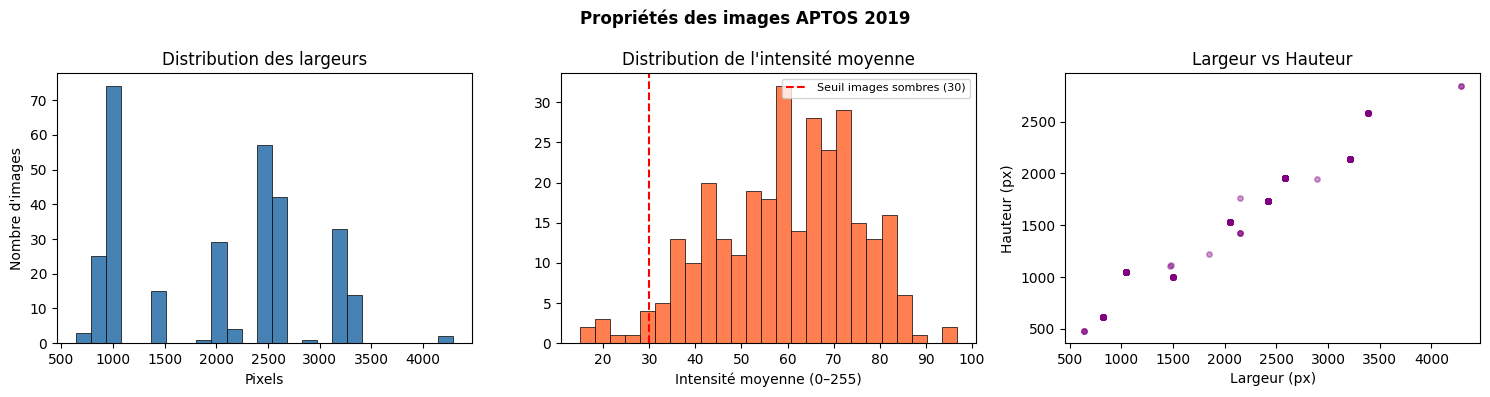

In [36]:
print("=== ANALYSE DES PROPRIÉTÉS DES IMAGES ===\n")

# ── Scan d'un sous-ensemble pour la rapidité ────────────────
SAMPLE_SIZE = 300
sample_ids = df_train['id_code'].sample(SAMPLE_SIZE, random_state=42).values

dimensions, pixel_means, dark_ids, aspect_ratios = [], [], [], []

for img_id in sample_ids:
    for ext in ['.png', '.jpeg', '.jpg']:
        path = os.path.join(TRAIN_DIR, img_id + ext)
        if os.path.exists(path):
            try:
                with Image.open(path) as pil_img:
                    w, h = pil_img.size
                    dimensions.append((w, h))
                    aspect_ratios.append(w / h)

                img_cv = cv2.imread(path)
                img_rgb = cv2.cvtColor(img_cv, cv2.COLOR_BGR2RGB)
                mean_val = np.mean(img_rgb)
                pixel_means.append(mean_val)
                if mean_val < 30:
                    dark_ids.append(img_id)
            except Exception as e:
                pass
            break

widths  = [d[0] for d in dimensions]
heights = [d[1] for d in dimensions]

print(f"[DIMENSIONS] (sur {len(dimensions)} images)")
print(f"  Largeur  — min: {min(widths)}, max: {max(widths)}, moy: {np.mean(widths):.0f} px")
print(f"  Hauteur  — min: {min(heights)}, max: {max(heights)}, moy: {np.mean(heights):.0f} px")
print(f"  Ratio H/W — min: {min(aspect_ratios):.2f}, max: {max(aspect_ratios):.2f}, moy: {np.mean(aspect_ratios):.2f}")

print(f"\n[QUALITÉ]")
print(f"  Intensité moyenne — min: {min(pixel_means):.1f}, max: {max(pixel_means):.1f}, moy: {np.mean(pixel_means):.1f}")
print(f"  Images très sombres (moy < 30) : {len(dark_ids)} ({len(dark_ids)/SAMPLE_SIZE*100:.1f}%)")

top_dims = Counter(dimensions).most_common(8)
print(f"\n[TOP 8 RÉSOLUTIONS]")
for dim, cnt in top_dims:
    print(f"  {dim[0]:4d} × {dim[1]:4d} : {cnt:3d} images")

# ── Visualisation ────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Propriétés des images APTOS 2019', fontsize=12, fontweight='bold')

axes[0].hist(widths, bins=25, color='steelblue', edgecolor='black', linewidth=0.5)
axes[0].set_title('Distribution des largeurs')
axes[0].set_xlabel('Pixels')
axes[0].set_ylabel('Nombre d\'images')

axes[1].hist(pixel_means, bins=25, color='coral', edgecolor='black', linewidth=0.5)
axes[1].axvline(30, color='red', linestyle='--', label='Seuil images sombres (30)')
axes[1].set_title('Distribution de l\'intensité moyenne')
axes[1].set_xlabel('Intensité moyenne (0–255)')
axes[1].legend(fontsize=8)

axes[2].scatter(widths, heights, alpha=0.4, color='purple', s=15)
axes[2].set_title('Largeur vs Hauteur')
axes[2].set_xlabel('Largeur (px)')
axes[2].set_ylabel('Hauteur (px)')

plt.tight_layout()
plt.savefig('eda_image_properties.png', dpi=150, bbox_inches='tight')
plt.show()

# Analyse des statistiques par classe

=== STATISTIQUES PAR CLASSE (canal vert - le plus informatif en rétinographie) ===



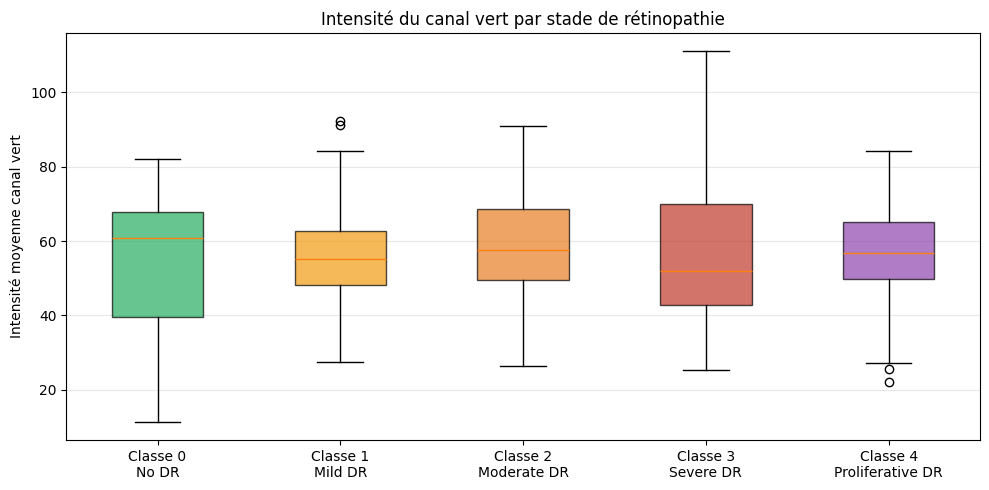

In [37]:
# Statistiques pixel moyennes selon le stade DR
# Utile pour vérifier si les classes diffèrent visuellement en intensité

print("=== STATISTIQUES PAR CLASSE (canal vert - le plus informatif en rétinographie) ===\n")

class_green_means = {i: [] for i in range(5)}

sample_per_class = 80
for label in range(5):
    samples = df_train[df_train['diagnosis'] == label].sample(
        min(sample_per_class, class_counts[label]), random_state=42
    )
    for _, row in samples.iterrows():
        for ext in ['.png', '.jpeg', '.jpg']:
            path = os.path.join(TRAIN_DIR, row['id_code'] + ext)
            if os.path.exists(path):
                img = cv2.imread(path)
                if img is not None:
                    class_green_means[label].append(np.mean(img[:,:,1]))  # canal vert (BGR[1])
                break

fig, ax = plt.subplots(figsize=(10, 5))
data_to_plot = [class_green_means[i] for i in range(5)]
bp = ax.boxplot(data_to_plot, patch_artist=True, notch=False)
for patch, color in zip(bp['boxes'], COLORS):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_xticklabels([f'Classe {i}\n{CLASS_NAMES[i]}' for i in range(5)])
ax.set_title('Intensité du canal vert par stade de rétinopathie')
ax.set_ylabel('Intensité moyenne canal vert')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('eda_pixel_per_class.png', dpi=150, bbox_inches='tight')
plt.show()

# Synthèse de l'EDA (cellule Markdown + Print)

In [28]:
print("╔══════════════════════════════════════════════════════════╗")
print("║          SYNTHÈSE EDA — APTOS 2019                      ║")
print("╠══════════════════════════════════════════════════════════╣")
print("║  DATASET                                                  ║")
print(f"║   • {len(df_train)} images entraînement, {len(df_test)} images test          ║")
print(f"║   • 5 classes ordinales (0 = No DR → 4 = Proliferative)  ║")
print("╠══════════════════════════════════════════════════════════╣")
print("║  PROBLÈME IDENTIFIÉ : DÉSÉQUILIBRE SÉVÈRE               ║")
print(f"║   • Classe majoritaire : 0 ({class_counts[0]} imgs, {class_counts[0]/len(df_train)*100:.0f}%)         ║")
print(f"║   • Classe minoritaire : 3 ({class_counts[3]} imgs, {class_counts[3]/len(df_train)*100:.0f}%)          ║")
print(f"║   • Ratio max/min      : {class_counts.max()/class_counts.min():.0f}×                      ║")
print("╠══════════════════════════════════════════════════════════╣")
print("║  QUALITÉ DES IMAGES                                       ║")
print("║   • Résolutions variables → redimensionnement requis     ║")
print("║   • Variabilité d'exposition → CLAHE + Ben Graham        ║")
print("╠══════════════════════════════════════════════════════════╣")
print("║  DÉCISIONS POUR LES PHASES SUIVANTES                     ║")
print("║  Phase 2 → WeightedSampler + CLAHE + Ben Graham          ║")
print("║  Phase 3 → Benchmark équitable avec mêmes conditions     ║")
print("║  Phase 4 → Focal Loss pour gérer le déséquilibre         ║")
print("║  Phase 5 → Cohen's κ + F1-macro (résistants déséquilibre)║")
print("╚══════════════════════════════════════════════════════════╝")

╔══════════════════════════════════════════════════════════╗
║          SYNTHÈSE EDA — APTOS 2019                      ║
╠══════════════════════════════════════════════════════════╣
║  DATASET                                                  ║
║   • 2930 images entraînement, 366 images test          ║
║   • 5 classes ordinales (0 = No DR → 4 = Proliferative)  ║
╠══════════════════════════════════════════════════════════╣
║  PROBLÈME IDENTIFIÉ : DÉSÉQUILIBRE SÉVÈRE               ║
║   • Classe majoritaire : 0 (1434 imgs, 49%)         ║
║   • Classe minoritaire : 3 (154 imgs, 5%)          ║
║   • Ratio max/min      : 9×                      ║
╠══════════════════════════════════════════════════════════╣
║  QUALITÉ DES IMAGES                                       ║
║   • Résolutions variables → redimensionnement requis     ║
║   • Variabilité d'exposition → CLAHE + Ben Graham        ║
╠══════════════════════════════════════════════════════════╣
║  DÉCISIONS POUR LES PHASES SUIVANTES       

# PHASE 2:  Préprocessing & Augmentation

## Cellule 1 - Imports de la phase 2

In [29]:
# ============================================================
# SECTION 2 — PRÉPROCESSING & AUGMENTATION
# ============================================================

import cv2
import numpy as np
import pandas as pd
import albumentations as A
from albumentations.pytorch import ToTensorV2
import torch
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.model_selection import StratifiedKFold
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
import os

# ── Hyperparamètres de la phase ─────────────────────────────
IMG_SIZE    = 224      # 224 pour benchmark, 380 pour EfficientNet-B4 final
BATCH_SIZE  = 32
NUM_WORKERS = 2        # sur Kaggle, 2 est une valeur sûre
VAL_FOLD    = 0        # fold utilisé comme validation (StratifiedKFold)
N_FOLDS     = 5

## Cellule 2 - Circle crop

In [30]:
def crop_image_from_gray(img, tol=7):
    """
    Supprime les bandes noires autour de la rétine.

    La rétinographie est circulaire : les bords de l'image sont noirs
    (hors du champ optique). Ces pixels noirs ne contiennent aucune
    information pathologique et biaisent l'apprentissage.

    Paramètre tol : seuil d'intensité en dessous duquel un pixel
    est considéré comme 'vide'. 7 est empiriquement robuste sur APTOS.
    """
    if img.ndim == 2:
        mask = img > tol
        return img[np.ix_(mask.any(1), mask.any(0))]

    elif img.ndim == 3:
        gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
        mask = gray > tol

        # Vérification de sécurité : si l'image est trop sombre,
        # on retourne l'image originale sans crop
        check = img[:, :, 0][np.ix_(mask.any(1), mask.any(0))]
        if check.shape[0] == 0 or check.shape[1] == 0:
            return img

        img_cropped = img[np.ix_(mask.any(1), mask.any(0))]
        return img_cropped

## Cellule 3 - Ben Graham preprocessing

In [31]:
def ben_graham_preprocessing(img, sigmaX=30):
    """
    Préprocessing de Ben Graham — vainqueur Kaggle DR Competition 2015.

    Principe mathématique :
        output = α × img + β × GaussianBlur(img, σ) + γ
        avec α=4, β=-4, γ=128

    Ce que ça fait concrètement :
    ┌─────────────────────────────────────────────────────────┐
    │  GaussianBlur(img) ≈ composante basse fréquence        │
    │  (illumination globale, vignettage, gradients lents)   │
    │                                                         │
    │  img - GaussianBlur(img) = composante haute fréquence  │
    │  (microanévrismes, exsudats, bords de vaisseaux)       │
    │                                                         │
    │  ×4 + 128 → ramène dans [0, 255] avec contraste exagéré│
    └─────────────────────────────────────────────────────────┘

    Pourquoi sigmaX=30 ?
    À 30px sur une image 256-512px, le flou couvre les variations
    d'illumination régionales sans effacer les micro-structures.
    Valeur issue du papier original et validée sur APTOS dans
    plusieurs publications arxiv 2020-2023.
    """
    img = cv2.addWeighted(
        img,                                    # image originale  (α = 4)
        4,
        cv2.GaussianBlur(img, (0, 0), sigmaX), # image floutée    (β = -4)
        -4,
        128                                     # offset γ = 128 (centre à 128)
    )
    return img

## Cellule 4 - CLAHE

In [32]:
def apply_clahe(img, clip_limit=2.0, tile_grid_size=(8, 8)):
    """
    CLAHE — Contrast Limited Adaptive Histogram Equalization.

    Différence avec l'égalisation d'histogramme classique (HE) :
    ┌──────────────────┬──────────────────────────────────────┐
    │ HE global        │ Égalise sur toute l'image → amplifie │
    │                  │ le bruit dans les zones sombres      │
    ├──────────────────┼──────────────────────────────────────┤
    │ CLAHE            │ Divise l'image en tiles (ici 8×8),   │
    │                  │ égalise localement avec une limite   │
    │                  │ de contraste → préserve les détails  │
    │                  │ locaux sans sur-amplifier le bruit   │
    └──────────────────┴──────────────────────────────────────┘

    Pourquoi travailler en LAB ?
    L'espace LAB sépare la luminosité (L) des informations de
    couleur (A, B). On applique CLAHE uniquement sur L → on
    améliore le contraste sans altérer les couleurs, qui portent
    une information pathologique (rouge des hémorragies, jaune
    des exsudats).

    Paramètres :
      clip_limit=2.0    → limite l'amplification du contraste
                          (évite d'amplifier le bruit)
      tile_grid_size=8  → 8×8 = 64 tuiles locales sur l'image
    """
    # Convertir RGB → LAB
    img_lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)

    # Séparer les canaux
    l_channel, a_channel, b_channel = cv2.split(img_lab)

    # Appliquer CLAHE sur le canal L uniquement
    clahe = cv2.createCLAHE(
        clipLimit=clip_limit,
        tileGridSize=tile_grid_size
    )
    l_clahe = clahe.apply(l_channel)

    # Recombiner les canaux
    img_lab_clahe = cv2.merge([l_clahe, a_channel, b_channel])

    # Reconvertir LAB → RGB
    img_rgb = cv2.cvtColor(img_lab_clahe, cv2.COLOR_LAB2RGB)
    return img_rgb

## Cellule 5 -  Pipeline complet de chargement

In [33]:
def load_and_preprocess(img_id, directory, size=IMG_SIZE,
                        use_ben_graham=True, use_clahe=True,
                        sigmaX=30):
    """
    Pipeline de chargement complet pour une image APTOS.

    Ordre des opérations (important — l'ordre change le résultat) :
      1. Lecture BGR → conversion RGB
      2. Circle crop (supprime le fond noir)
      3. Ben Graham (rehausse les structures locales)
      4. CLAHE (améliore le contraste local)
      5. Resize vers la taille cible

    Note : CLAHE après Ben Graham car Ben Graham peut créer des
    artefacts d'intensité que CLAHE atténue ensuite.
    """
    # ── 1. Lecture ───────────────────────────────────────────
    img = None
    for ext in ['.png', '.jpeg', '.jpg']:
        path = os.path.join(directory, img_id + ext)
        if os.path.exists(path):
            img = cv2.imread(path)
            if img is not None:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                break

    if img is None:
        # Image manquante → retourne une image noire (ne crash pas)
        return np.zeros((size, size, 3), dtype=np.uint8)

    # ── 2. Circle crop ───────────────────────────────────────
    img = crop_image_from_gray(img)

    # Redimensionner pour que Ben Graham ait une base cohérente
    img = cv2.resize(img, (size, size))

    # ── 3. Ben Graham ────────────────────────────────────────
    if use_ben_graham:
        img = ben_graham_preprocessing(img, sigmaX=sigmaX)
        # Garantir que les valeurs restent dans [0, 255]
        img = np.clip(img, 0, 255).astype(np.uint8)

    # ── 4. CLAHE ─────────────────────────────────────────────
    if use_clahe:
        img = apply_clahe(img)

    return img.astype(np.uint8)

## Cellule 6 -  Visualisation comparative du preprocessing

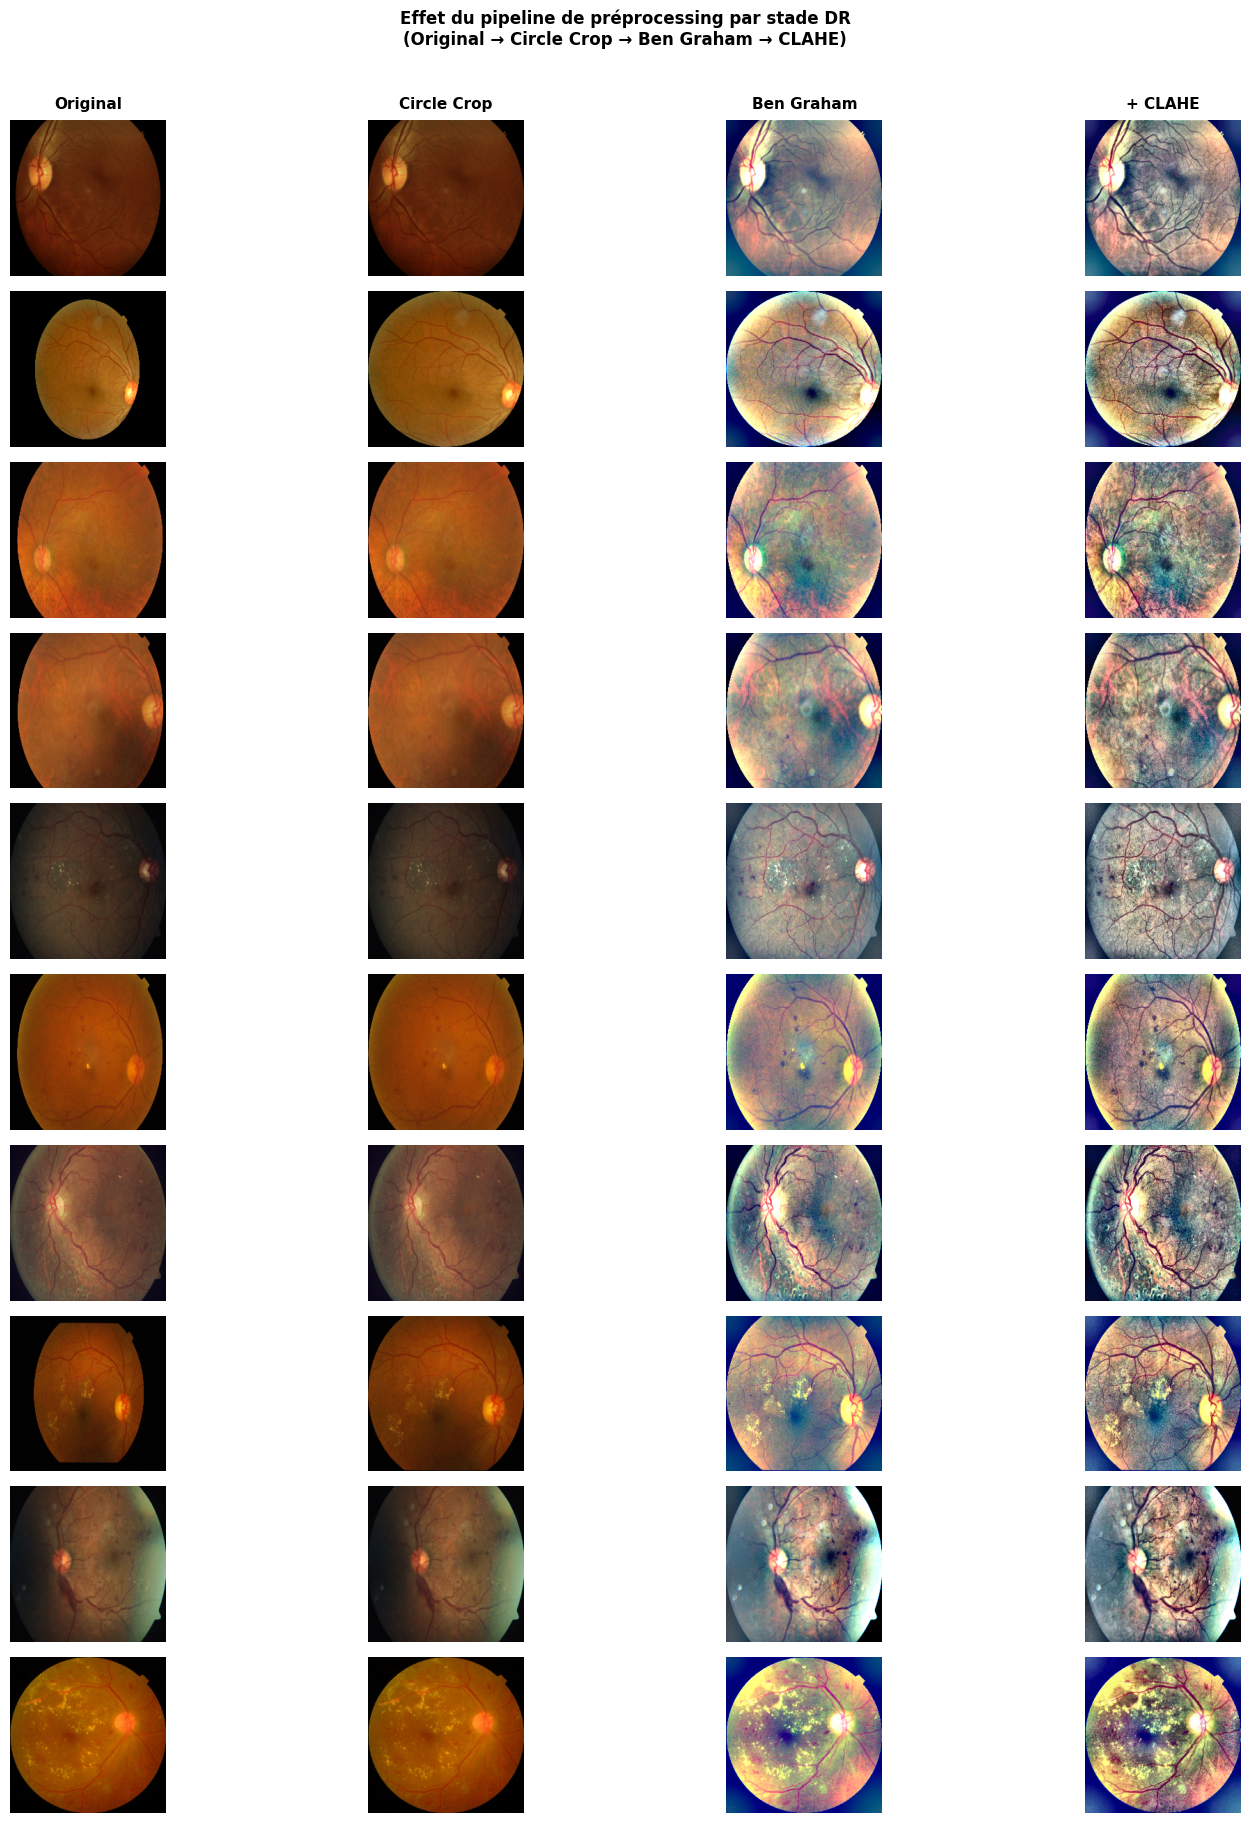

In [34]:
def visualize_preprocessing_pipeline(df, directory, n_per_class=2):
    """
    Affiche côte à côte l'image originale, après Ben Graham, et après CLAHE.
    Indispensable pour le notebook : montre visuellement l'effet de chaque étape.
    """
    fig, axes = plt.subplots(
        5 * n_per_class, 4,
        figsize=(16, 5 * n_per_class * 1.8)
    )
    fig.suptitle(
        'Effet du pipeline de préprocessing par stade DR\n'
        '(Original → Circle Crop → Ben Graham → CLAHE)',
        fontsize=12, fontweight='bold', y=1.01
    )

    col_titles = ['Original', 'Circle Crop', 'Ben Graham', '+ CLAHE']
    for ax, title in zip(axes[0], col_titles):
        ax.set_title(title, fontsize=11, fontweight='bold', pad=8)

    CLASS_COLORS = ['#27ae60', '#f39c12', '#e67e22', '#c0392b', '#8e44ad']
    CLASS_NAMES  = {0:'No DR', 1:'Mild', 2:'Moderate', 3:'Severe', 4:'Proliferative'}

    row_idx = 0
    for label in range(5):
        samples = df[df['diagnosis'] == label].sample(
            min(n_per_class, len(df[df['diagnosis'] == label])),
            random_state=42
        )
        for _, row in samples.iterrows():
            # Charger l'image originale
            img_orig = None
            for ext in ['.png', '.jpeg', '.jpg']:
                path = os.path.join(directory, row['id_code'] + ext)
                if os.path.exists(path):
                    img_orig = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)
                    break

            if img_orig is None:
                row_idx += 1
                continue

            # Les 4 étapes
            img_resize = cv2.resize(img_orig, (IMG_SIZE, IMG_SIZE))
            img_crop   = cv2.resize(crop_image_from_gray(img_orig), (IMG_SIZE, IMG_SIZE))
            img_bg     = np.clip(ben_graham_preprocessing(img_crop), 0, 255).astype(np.uint8)
            img_clahe  = apply_clahe(img_bg)

            images = [img_resize, img_crop, img_bg, img_clahe]

            for col_idx, im in enumerate(images):
                ax = axes[row_idx][col_idx]
                ax.imshow(im)
                ax.axis('off')
                # Colorier la bordure selon la classe
                for spine in ax.spines.values():
                    spine.set_visible(True)
                    spine.set_edgecolor(CLASS_COLORS[label])
                    spine.set_linewidth(2.5)

            # Label de la classe sur la première colonne
            axes[row_idx][0].set_ylabel(
                f'Classe {label}\n{CLASS_NAMES[label]}',
                fontsize=9, fontweight='bold',
                rotation=0, labelpad=70, va='center',
                color=CLASS_COLORS[label]
            )
            row_idx += 1

    plt.tight_layout()
    plt.savefig('preprocessing_pipeline.png', dpi=150, bbox_inches='tight')
    plt.show()

# Appel
df_train = pd.read_csv(TRAIN_CSV)
visualize_preprocessing_pipeline(df_train, TRAIN_DIR, n_per_class=2)

## Cellule 7 — Pipeline d'augmentation Albumentations

In [35]:
def get_transforms(phase: str, img_size: int = IMG_SIZE):
    """
    Pipelines d'augmentation différenciés par phase.

    PHILOSOPHIE :
    ┌─────────────┬───────────────────────────────────────────┐
    │ Train       │ Augmentation forte → régularisation,      │
    │             │ robustesse aux variations d'acquisition   │
    ├─────────────┼───────────────────────────────────────────┤
    │ Val / Test  │ Aucune augmentation aléatoire →           │
    │             │ évaluation reproductible et équitable     │
    └─────────────┴───────────────────────────────────────────┘

    Justification de chaque transformation :

    ▸ HorizontalFlip / VerticalFlip
      Les rétines gauche et droite sont des miroirs l'une de
      l'autre. Un flip horizontal crée une rétine "controlatérale"
      valide cliniquement. Même raisonnement pour le flip vertical.

    ▸ RandomRotate90 + Rotate(limit=45)
      La caméra peut être positionnée dans n'importe quelle
      orientation. La rotation simule ces variations d'acquisition.
      limit=45° : au-delà, le contexte anatomique est trop altéré.

    ▸ RandomBrightnessContrast
      Simule des variations d'exposition entre caméras et patients.
      Directement motivé par la variabilité observée en EDA.

    ▸ HueSaturationValue
      Les rétinographies varient en teinte selon le pigment
      choroïdien (plus visible chez les patients à peau claire).

    ▸ GaussNoise / GaussianBlur
      Simule le bruit de capteur et les légères mises au point
      imparfaites — fréquents en contexte clinique réel.

    ▸ GridDistortion
      Simule de légères distorsions optiques des lentilles.
      p=0.2 : appliquée rarement pour ne pas trop déformer
      les structures vasculaires.

    ▸ CoarseDropout (Cutout)
      Masque aléatoirement des patches de l'image → force le
      modèle à ne pas sur-spécialiser sur une région particulière.
      Technique de régularisation validée en vision médicale.

    ▸ Normalize avec mean/std ImageNet
      Obligatoire si on utilise des poids pré-entraînés ImageNet.
      Les modèles timm attendent des images normalisées avec ces
      statistiques spécifiques.
    """

    # ── Statistiques ImageNet (pour transfer learning) ───────
    IMAGENET_MEAN = [0.485, 0.456, 0.406]
    IMAGENET_STD  = [0.229, 0.224, 0.225]

    if phase == 'train':
        return A.Compose([
            A.Resize(img_size, img_size),

            # ── Flips (p=0.5 : 50% de chance) ───────────────
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.5),

            # ── Rotations ────────────────────────────────────
            A.RandomRotate90(p=0.5),
            A.Rotate(limit=45, p=0.5, border_mode=cv2.BORDER_CONSTANT),

            # ── Photométrique ─────────────────────────────────
            A.RandomBrightnessContrast(
                brightness_limit=0.2,
                contrast_limit=0.2,
                p=0.5
            ),
            A.HueSaturationValue(
                hue_shift_limit=10,
                sat_shift_limit=20,
                val_shift_limit=10,
                p=0.3
            ),
            A.CLAHE(clip_limit=2.0, p=0.3),  # CLAHE léger supplémentaire

            # ── Bruit et flou ─────────────────────────────────
            A.OneOf([
                A.GaussNoise(var_limit=(10, 50), p=1.0),
                A.GaussianBlur(blur_limit=(3, 5), p=1.0),
                A.MotionBlur(blur_limit=5, p=1.0),
            ], p=0.2),

            # ── Distorsion géométrique légère ─────────────────
            A.GridDistortion(num_steps=5, distort_limit=0.1, p=0.2),

            # ── Régularisation (Cutout) ───────────────────────
            A.CoarseDropout(
                max_holes=8,
                max_height=img_size // 10,
                max_width=img_size // 10,
                min_holes=1,
                fill_value=0,
                p=0.3
            ),

            # ── Normalisation + Tensor ────────────────────────
            A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
            ToTensorV2()
        ])

    else:  # 'val' ou 'test'
        return A.Compose([
            A.Resize(img_size, img_size),
            A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
            ToTensorV2()
        ])

## Cellule 8 — Dataset PyTorch customisé

In [36]:
class APTOSDataset(Dataset):
    """
    Dataset PyTorch pour APTOS 2019.

    Hérite de torch.utils.data.Dataset et implémente les 3 méthodes
    obligatoires : __init__, __len__, __getitem__.

    Le preprocessing est appliqué lors du __getitem__ (à la volée)
    et non au chargement (en mémoire) → économie de RAM sur Kaggle.
    """

    def __init__(self, df, img_dir, transform=None, phase='train'):
        """
        Args:
            df        : DataFrame avec colonnes 'id_code' et 'diagnosis'
            img_dir   : chemin vers le dossier d'images
            transform : pipeline albumentations
            phase     : 'train', 'val', ou 'test'
        """
        self.df        = df.reset_index(drop=True)
        self.img_dir   = img_dir
        self.transform = transform
        self.phase     = phase

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row    = self.df.iloc[idx]
        img_id = row['id_code']

        # ── Chargement + préprocessing médical ───────────────
        img = load_and_preprocess(
            img_id,
            self.img_dir,
            size=IMG_SIZE,
            use_ben_graham=True,
            use_clahe=True
        )

        # ── Augmentation Albumentations ───────────────────────
        if self.transform:
            augmented = self.transform(image=img)
            img = augmented['image']  # → tenseur [C, H, W] float32

        # ── Label ─────────────────────────────────────────────
        if self.phase == 'test':
            return img

        label = torch.tensor(row['diagnosis'], dtype=torch.long)
        return img, label

## Cellule 9 — Split stratifié + WeightedRandomSampler

In [37]:
def create_dataloaders(df, img_dir, fold=VAL_FOLD, n_folds=N_FOLDS):
    """
    Crée les DataLoaders train et val avec split stratifié.

    StratifiedKFold garantit que chaque fold a la même proportion
    de chaque classe → la validation est toujours représentative,
    même pour les classes très minoritaires (classe 1 et 3).

    WeightedRandomSampler :
    ─────────────────────
    Pour chaque exemple i de classe c, son poids w_i = 1 / n_c
    où n_c est le nombre total d'exemples de la classe c.

    Effet : à chaque epoch, le sampler tire autant d'exemples de
    chaque classe, indépendamment de leur fréquence naturelle.

    Exemple avec APTOS :
      Classe 0 : 1805 images → w = 1/1805 ≈ 0.00055
      Classe 3 :  193 images → w = 1/193  ≈ 0.00518
      → Classe 3 est 9.3× plus susceptible d'être tirée par step
    """

    # ── Split stratifié ───────────────────────────────────────
    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)
    splits = list(skf.split(df['id_code'], df['diagnosis']))
    train_idx, val_idx = splits[fold]

    df_train_fold = df.iloc[train_idx].reset_index(drop=True)
    df_val_fold   = df.iloc[val_idx].reset_index(drop=True)

    print(f"[Split fold {fold}]")
    print(f"  Train : {len(df_train_fold)} images")
    print(f"  Val   : {len(df_val_fold)} images")
    print(f"\n  Distribution train par classe :")
    for lbl, cnt in df_train_fold['diagnosis'].value_counts().sort_index().items():
        print(f"    Classe {lbl} : {cnt} images ({cnt/len(df_train_fold)*100:.1f}%)")

    # ── Calcul des poids pour WeightedRandomSampler ───────────
    class_counts_train = df_train_fold['diagnosis'].value_counts().sort_index()
    class_weights      = 1.0 / class_counts_train.values.astype(float)

    # Assigner le poids de sa classe à chaque exemple
    sample_weights = np.array([
        class_weights[label]
        for label in df_train_fold['diagnosis'].values
    ])
    sample_weights_tensor = torch.DoubleTensor(sample_weights)

    sampler = WeightedRandomSampler(
        weights     = sample_weights_tensor,
        num_samples = len(df_train_fold),  # tirer autant que la taille du train set
        replacement = True                 # avec remise (nécessaire pour sur-échantillonner)
    )

    # ── Création des datasets ─────────────────────────────────
    train_dataset = APTOSDataset(
        df_train_fold, img_dir,
        transform=get_transforms('train', IMG_SIZE),
        phase='train'
    )
    val_dataset = APTOSDataset(
        df_val_fold, img_dir,
        transform=get_transforms('val', IMG_SIZE),
        phase='val'
    )

    # ── DataLoaders ───────────────────────────────────────────
    train_loader = DataLoader(
        train_dataset,
        batch_size  = BATCH_SIZE,
        sampler     = sampler,    # remplace shuffle=True !
        num_workers = NUM_WORKERS,
        pin_memory  = True,       # accélère le transfert CPU→GPU
        drop_last   = True        # évite un batch trop petit en fin d'epoch
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size  = BATCH_SIZE * 2,  # val : pas de backprop → batch plus grand possible
        shuffle     = False,
        num_workers = NUM_WORKERS,
        pin_memory  = True
    )

    return train_loader, val_loader, df_train_fold, df_val_fold


# ── Appel ─────────────────────────────────────────────────────
train_loader, val_loader, df_train_fold, df_val_fold = create_dataloaders(
    df_train, TRAIN_DIR
)
print(f"\n  Batches train : {len(train_loader)}")
print(f"  Batches val   : {len(val_loader)}")

[Split fold 0]
  Train : 2344 images
  Val   : 586 images

  Distribution train par classe :
    Classe 0 : 1147 images (48.9%)
    Classe 1 : 240 images (10.2%)
    Classe 2 : 646 images (27.6%)
    Classe 3 : 124 images (5.3%)
    Classe 4 : 187 images (8.0%)

  Batches train : 73
  Batches val   : 10


## Cellule 10 — Vérification visuelle du sampler

In [38]:
def verify_sampler_balance(loader, n_batches=5):
    """
    Vérifie que le WeightedRandomSampler équilibre bien les classes
    en inspectant les labels des premiers batches.

    Si le sampler fonctionne, chaque classe devrait apparaître
    approximativement BATCH_SIZE/5 fois par batch (≈6-7 fois pour bs=32).
    """
    print("=== VÉRIFICATION DU WEIGHTED SAMPLER ===\n")
    print(f"Distribution attendue si équilibrée : ~{BATCH_SIZE // 5} exemples/classe/batch\n")

    label_counts_total = np.zeros(5, dtype=int)

    for batch_idx, (images, labels) in enumerate(loader):
        if batch_idx >= n_batches:
            break
        counts = np.bincount(labels.numpy(), minlength=5)
        label_counts_total += counts
        dist = ' | '.join([f'C{i}:{counts[i]:2d}' for i in range(5)])
        print(f"  Batch {batch_idx+1} : {dist}")

    print(f"\n  Total sur {n_batches} batches : {label_counts_total}")
    print(f"  Ratio max/min observé : {label_counts_total.max()/label_counts_total.min():.2f}×")
    print(f"  (avant sampler le ratio était ~{df_train['diagnosis'].value_counts().max() / df_train['diagnosis'].value_counts().min():.1f}×)")

verify_sampler_balance(train_loader)

=== VÉRIFICATION DU WEIGHTED SAMPLER ===

Distribution attendue si équilibrée : ~6 exemples/classe/batch

  Batch 1 : C0: 8 | C1: 5 | C2: 7 | C3: 6 | C4: 6
  Batch 2 : C0: 8 | C1:10 | C2: 5 | C3: 5 | C4: 4
  Batch 3 : C0:10 | C1: 7 | C2: 5 | C3: 4 | C4: 6
  Batch 4 : C0: 5 | C1: 5 | C2: 8 | C3: 6 | C4: 8
  Batch 5 : C0: 6 | C1:11 | C2: 6 | C3: 4 | C4: 5

  Total sur 5 batches : [37 38 31 25 29]
  Ratio max/min observé : 1.52×
  (avant sampler le ratio était ~9.3×)


## Cellule 11 — Visualisation d'un batch augmenté

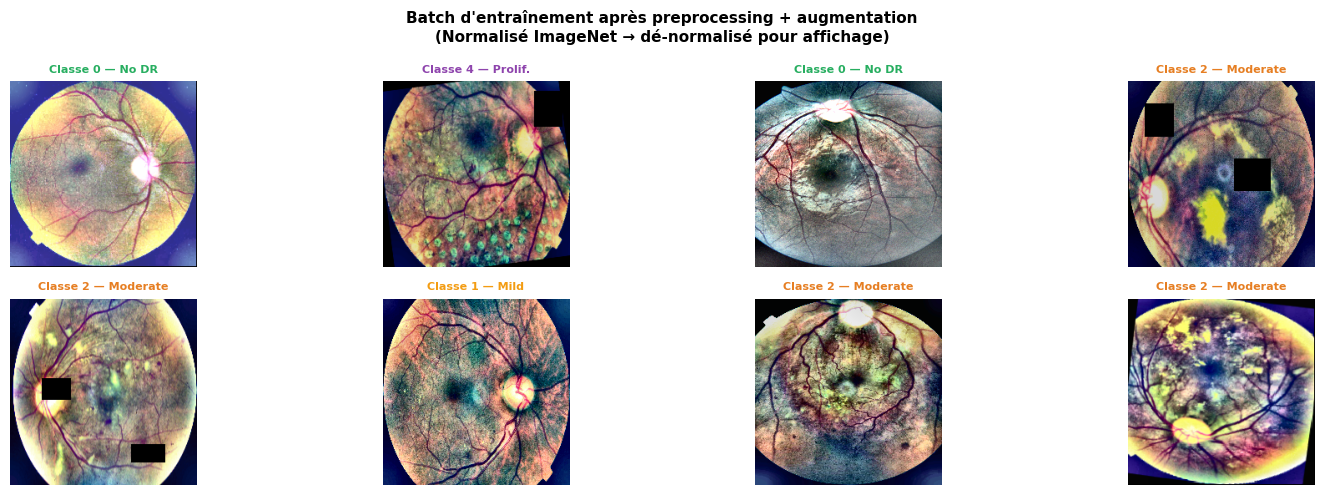

In [39]:
def show_augmented_batch(loader, n_images=8):
    """
    Affiche des images d'un batch après preprocessing + augmentation.
    Permet de vérifier visuellement que les transformations sont
    raisonnables et ne détruisent pas l'information pathologique.
    """
    IMAGENET_MEAN = np.array([0.485, 0.456, 0.406])
    IMAGENET_STD  = np.array([0.229, 0.224, 0.225])
    CLASS_NAMES   = {0:'No DR', 1:'Mild', 2:'Moderate', 3:'Severe', 4:'Prolif.'}
    COLORS        = ['#27ae60', '#f39c12', '#e67e22', '#c0392b', '#8e44ad']

    images, labels = next(iter(loader))

    fig, axes = plt.subplots(2, n_images // 2, figsize=(n_images * 2, 5))
    axes = axes.flatten()
    fig.suptitle(
        'Batch d\'entraînement après preprocessing + augmentation\n'
        '(Normalisé ImageNet → dé-normalisé pour affichage)',
        fontsize=11, fontweight='bold'
    )

    for i in range(n_images):
        # Dé-normalisation pour affichage
        img = images[i].permute(1, 2, 0).numpy()  # [C,H,W] → [H,W,C]
        img = img * IMAGENET_STD + IMAGENET_MEAN   # inverse de normalize
        img = np.clip(img, 0, 1)

        label = labels[i].item()

        axes[i].imshow(img)
        axes[i].set_title(
            f'Classe {label} — {CLASS_NAMES[label]}',
            fontsize=8, color=COLORS[label], fontweight='bold'
        )
        axes[i].axis('off')
        # Bordure colorée selon la classe
        for spine in axes[i].spines.values():
            spine.set_visible(True)
            spine.set_edgecolor(COLORS[label])
            spine.set_linewidth(2)

    plt.tight_layout()
    plt.savefig('augmented_batch.png', dpi=150, bbox_inches='tight')
    plt.show()

show_augmented_batch(train_loader, n_images=8)

## Cellule 12 — Synthèse Phase 2

In [40]:
print("╔══════════════════════════════════════════════════════════╗")
print("║        SYNTHÈSE — PHASE 2 PRÉPROCESSING                  ║")
print("╠══════════════════════════════════════════════════════════╣")
print("║  PIPELINE MÉDICAL                                         ║")
print("║   1. Circle Crop    → supprime fond noir (0 info)        ║")
print("║   2. Ben Graham     → rehausse structures locales        ║")
print("║   3. CLAHE (LAB)    → contraste local sans bruit         ║")
print("╠══════════════════════════════════════════════════════════╣")
print("║  AUGMENTATION (train uniquement)                          ║")
print("║   • Flips H/V       → rétines gauche/droite              ║")
print("║   • Rotations ±45°  → variations orientation caméra      ║")
print("║   • Photométrique   → variabilité d'acquisition          ║")
print("║   • CoarseDropout   → régularisation (Cutout)            ║")
print("╠══════════════════════════════════════════════════════════╣")
print("║  GESTION DU DÉSÉQUILIBRE                                  ║")
print(f"║   • Ratio original : {df_train['diagnosis'].value_counts().max() / df_train['diagnosis'].value_counts().min():.0f}× entre C0 et C3               ║")
print("║   • WeightedSampler → ratio ≈ 1× par batch              ║")
print("║   • Focal Loss (Phase 4) → complément au sampler         ║")
print("╠══════════════════════════════════════════════════════════╣")
print("║  NORMALISATION                                            ║")
print("║   • Mean [0.485, 0.456, 0.406] — ImageNet                ║")
print("║   • Std  [0.229, 0.224, 0.225] — ImageNet                ║")
print("║   → Obligatoire pour poids pré-entraînés (Phase 3)       ║")
print("╚══════════════════════════════════════════════════════════╝")

╔══════════════════════════════════════════════════════════╗
║        SYNTHÈSE — PHASE 2 PRÉPROCESSING                  ║
╠══════════════════════════════════════════════════════════╣
║  PIPELINE MÉDICAL                                         ║
║   1. Circle Crop    → supprime fond noir (0 info)        ║
║   2. Ben Graham     → rehausse structures locales        ║
║   3. CLAHE (LAB)    → contraste local sans bruit         ║
╠══════════════════════════════════════════════════════════╣
║  AUGMENTATION (train uniquement)                          ║
║   • Flips H/V       → rétines gauche/droite              ║
║   • Rotations ±45°  → variations orientation caméra      ║
║   • Photométrique   → variabilité d'acquisition          ║
║   • CoarseDropout   → régularisation (Cutout)            ║
╠══════════════════════════════════════════════════════════╣
║  GESTION DU DÉSÉQUILIBRE                                  ║
║   • Ratio original : 9× entre C0 et C3               ║
║   • WeightedSampler → r

# PHASE 3 : BENCHMARK DES MODÈLES

## Cellule 1 — Imports & setup Phase 3

In [41]:
# ============================================================
# SECTION 3 — BENCHMARK DES MODÈLES
# Objectif : comparer 5 architectures dans des conditions
# strictement identiques pour justifier le choix final
# ============================================================

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
import timm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import time
import copy
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import (
    cohen_kappa_score,
    f1_score,
    accuracy_score,
    confusion_matrix
)

# ── Device ───────────────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
    print(f"VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

# ── Hyperparamètres du benchmark ────────────────────────────
# RÈGLE FONDAMENTALE : ces valeurs ne changent PAS entre modèles
# Toute différence de performance vient de l'architecture, pas du protocole
BENCHMARK_CONFIG = {
    'epochs'        : 10,       # assez pour voir le potentiel, pas pour l'overfit
    'batch_size'    : 32,
    'lr'            : 1e-3,     # lr de la tête de classification uniquement
    'weight_decay'  : 1e-4,
    'num_classes'   : 5,
    'img_size'      : 224,      # résolution unifiée pour le benchmark
    'seed'          : 42,
}

# Fix de toutes les sources d'aléatoire — reproductibilité totale
def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(BENCHMARK_CONFIG['seed'])
print(f"\nConfig benchmark : {BENCHMARK_CONFIG}")

Device : cpu

Config benchmark : {'epochs': 10, 'batch_size': 32, 'lr': 0.001, 'weight_decay': 0.0001, 'num_classes': 5, 'img_size': 224, 'seed': 42}


## Cellule 2 — CNN Baseline from scratch

In [42]:
# ============================================================
# MODÈLE 1 : CNN BASELINE (from scratch)
# Rôle dans le benchmark : référence SANS transfer learning
# Son score intentionnellement bas prouvera l'apport des
# modèles pré-entraînés — argument clé pour le jury
# ============================================================

class ConvBlock(nn.Module):
    """
    Bloc Conv → BatchNorm → ReLU → MaxPool.

    BatchNorm placée APRÈS Conv et AVANT l'activation :
    - Normalise les activations intermédiaires
    - Stabilise l'entraînement (gradient plus stable)
    - Permet d'utiliser un lr plus élevé
    - Réduit la dépendance à l'initialisation des poids

    MaxPool(2,2) divise par 2 la résolution spatiale → compacte
    les features et augmente le champ réceptif effectif.
    """
    def __init__(self, in_channels, out_channels, pool=True):
        super().__init__()
        layers = [
            nn.Conv2d(in_channels, out_channels,
                      kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        ]
        if pool:
            layers.append(nn.MaxPool2d(2, 2))
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)


class CNNBaseline(nn.Module):
    """
    CNN 4 blocs from scratch pour la détection de RD.

    Architecture :
      Input [B, 3, 224, 224]
        → ConvBlock(3→32)   → [B, 32, 112, 112]
        → ConvBlock(32→64)  → [B, 64,  56,  56]
        → ConvBlock(64→128) → [B, 128, 28,  28]
        → ConvBlock(128→256)→ [B, 256, 14,  14]
        → AdaptiveAvgPool  → [B, 256, 1, 1]
        → Flatten + Dropout → [B, 256]
        → Linear(256→5)    → [B, 5]

    AdaptiveAvgPool2d(1,1) :
    Quelque soit la résolution en entrée du classifieur, on sort
    toujours un vecteur 256-dim. Rend le modèle indépendant de
    la résolution d'entrée (utile si on change IMG_SIZE).

    Dropout(0.5) : régularisation — évite l'overfitting sur le
    petit dataset APTOS, fréquent avec les CNNs from scratch.
    """
    def __init__(self, num_classes=5):
        super().__init__()
        self.features = nn.Sequential(
            ConvBlock(3,   32,  pool=True),   # 224 → 112
            ConvBlock(32,  64,  pool=True),   # 112 → 56
            ConvBlock(64,  128, pool=True),   # 56  → 28
            ConvBlock(128, 256, pool=True),   # 28  → 14
        )
        self.pool       = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = self.classifier(x)
        return x


def count_parameters(model):
    """Compte les paramètres entraînables d'un modèle."""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


# ── Test rapide du CNN baseline ──────────────────────────────
cnn_test = CNNBaseline(num_classes=5)
dummy    = torch.randn(2, 3, 224, 224)
out      = cnn_test(dummy)
print(f"CNN Baseline — output shape : {out.shape}")
print(f"CNN Baseline — paramètres   : {count_parameters(cnn_test):,}")
del cnn_test, dummy, out

CNN Baseline — output shape : torch.Size([2, 5])
CNN Baseline — paramètres   : 390,181


## Cellule 3 — Factory de modèles pré-entraînés

In [43]:
# ============================================================
# MODÈLES 2-5 : ARCHITECTURES PRÉ-ENTRAÎNÉES via timm
#
# timm (PyTorch Image Models) — Ross Wightman, 2019
# Librairie de référence en vision academique et industrielle
# Plus de 700 architectures avec poids ImageNet disponibles
# pip install timm
# ============================================================

def build_model(model_name: str, num_classes: int = 5,
                pretrained: bool = True) -> nn.Module:
    """
    Construit un modèle pour le benchmark en mode feature extraction.

    MODE FEATURE EXTRACTION (Phase 3) :
    ┌──────────────────────────────────────────────────────────┐
    │  Backbone (couches conv)  : GELÉ   → requires_grad=False │
    │  Tête de classification   : LIBRE  → requires_grad=True  │
    └──────────────────────────────────────────────────────────┘

    Pourquoi geler le backbone ?
    → Comparaison équitable : on mesure la qualité des features
      ImageNet de chaque architecture, pas sa capacité à
      s'adapter avec un fine-tuning long.
    → Rapidité : 10 epochs suffisent pour entraîner une tête
      linéaire, mais pas pour un fine-tuning complet.
    → La Phase 4 fera le fine-tuning complet du MEILLEUR modèle.

    Architectures et leurs particularités :

    ResNet-50 (He et al., 2016) :
      - Skip connections (residual) → gradient flow stable
      - 25.6M paramètres, feature_dim = 2048
      - Référence absolue depuis 7 ans en vision par ordinateur

    EfficientNet-B0 (Tan & Le, ICML 2019) :
      - Compound scaling (depth + width + resolution)
      - 5.3M paramètres, très efficace par param
      - Baseline de la famille EfficientNet

    EfficientNet-B4 (Tan & Le, ICML 2019) :
      - Scaled-up version de B0 (résolution 380×380 en prod)
      - 19.3M paramètres, SOTA sur APTOS dans la littérature
      - Plusieurs papiers arxiv 2020-2023 reportent κ > 0.90

    DenseNet-121 (Huang et al., CVPR 2017) :
      - Dense connections : chaque couche reçoit les features
        de TOUTES les couches précédentes
      - Avantage en datasets médicaux limités (CheXNet)
      - 7.9M paramètres, feature reuse maximal
    """

    if model_name == 'cnn_baseline':
        model = CNNBaseline(num_classes=num_classes)
        # Pas de backbone à geler — tout est entraînable
        return model

    # ── Chargement via timm ──────────────────────────────────
    model = timm.create_model(
        model_name,
        pretrained=pretrained,
        num_classes=num_classes
    )

    # ── Gel du backbone (feature extraction) ─────────────────
    for param in model.parameters():
        param.requires_grad = False

    # ── Dégel de la tête de classification uniquement ────────
    # La tête s'appelle 'classifier' dans EfficientNet et DenseNet,
    # 'fc' dans ResNet — timm standardise avec get_classifier()
    classifier = model.get_classifier()
    for param in classifier.parameters():
        param.requires_grad = True

    return model


# ── Registre des modèles du benchmark ────────────────────────
MODELS_REGISTRY = {
    'CNN Baseline'    : 'cnn_baseline',
    'ResNet-50'       : 'resnet50',
    'EfficientNet-B0' : 'efficientnet_b0',
    'EfficientNet-B4' : 'efficientnet_b4',
    'DenseNet-121'    : 'densenet121',
}

# ── Vérification et affichage du registre ───────────────────
print("=" * 62)
print(f"{'Modèle':<20} {'Params totaux':>14} {'Params entraîn.':>16}")
print("=" * 62)

for display_name, model_id in MODELS_REGISTRY.items():
    model = build_model(model_id)
    total   = sum(p.numel() for p in model.parameters())
    trainable = count_parameters(model)
    print(f"{display_name:<20} {total/1e6:>12.2f}M {trainable/1e6:>14.2f}M")
    del model

print("=" * 62)
print("\n✓ Tous les modèles instanciés avec succès")

Modèle                Params totaux  Params entraîn.
CNN Baseline                 0.39M           0.39M


model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

ResNet-50                   23.52M           0.01M


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

EfficientNet-B0              4.01M           0.01M


model.safetensors:   0%|          | 0.00/77.9M [00:00<?, ?B/s]

EfficientNet-B4             17.56M           0.01M


model.safetensors:   0%|          | 0.00/32.3M [00:00<?, ?B/s]

DenseNet-121                 6.96M           0.01M

✓ Tous les modèles instanciés avec succès


## Cellule 4 — Calcul des poids de classe

In [44]:
# ============================================================
# POIDS DE CLASSE POUR LA CROSSENTROPYLOSS
#
# Complément au WeightedRandomSampler de la Phase 2.
# Même si le sampler équilibre les batches, la loss pondérée
# ajoute une pénalité supplémentaire sur les erreurs
# concernant les classes minoritaires.
#
# Formule : w_c = N_total / (N_classes × N_c)
# où N_c = nombre d'images de la classe c
# ============================================================

def compute_class_weights(df, num_classes=5):
    """
    Calcule les poids de classe inversement proportionnels
    à la fréquence dans le dataset d'entraînement.
    """
    counts  = df['diagnosis'].value_counts().sort_index().values
    weights = len(df) / (num_classes * counts)
    weights = weights / weights.sum() * num_classes  # normalisation

    print("Poids de classe pour CrossEntropyLoss :")
    for i, (w, c) in enumerate(zip(weights, counts)):
        print(f"  Classe {i} ({c:4d} imgs) → poids = {w:.4f}")

    return torch.FloatTensor(weights).to(DEVICE)


class_weights = compute_class_weights(df_train_fold)

Poids de classe pour CrossEntropyLoss :
  Classe 0 (1147 imgs) → poids = 0.2180
  Classe 1 ( 240 imgs) → poids = 1.0417
  Classe 2 ( 646 imgs) → poids = 0.3870
  Classe 3 ( 124 imgs) → poids = 2.0163
  Classe 4 ( 187 imgs) → poids = 1.3370


## Cellule 5 — Fonctions de métriques

In [45]:
# ============================================================
# MÉTRIQUES D'ÉVALUATION
#
# Pourquoi ces métriques pour la RD ?
#
# Cohen's Quadratic Weighted Kappa (κ) :
#   - Métrique officielle du challenge APTOS 2019 (Kaggle)
#   - Mesure l'accord entre prédictions et annotations experts
#   - "Quadratic" : pénalise davantage les erreurs éloignées
#     (confondre 0 et 4 est bien plus grave que 0 et 1)
#   - Corrige pour l'accord dû au hasard
#   - Interprétation : <0.4 mauvais, 0.6-0.8 bon, >0.8 excellent
#
# F1-Score macro :
#   - Moyenne non pondérée du F1 de chaque classe
#   - Insensible au déséquilibre (chaque classe compte autant)
#   - Complémentaire au κ
#
# Accuracy :
#   - Mettre en regard du κ pour montrer le déséquilibre
#   - Une accuracy de 75% peut masquer 0% sur les classes rares
# ============================================================

def evaluate_model(model, loader, criterion, device):
    """
    Évalue le modèle sur un DataLoader.
    Retourne loss, accuracy, cohen_kappa, f1_macro, et les prédictions.
    """
    model.eval()
    all_preds  = []
    all_labels = []
    total_loss = 0.0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss    = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)

    avg_loss = total_loss / len(loader.dataset)
    acc      = accuracy_score(all_labels, all_preds)
    kappa    = cohen_kappa_score(all_labels, all_preds, weights='quadratic')
    f1       = f1_score(all_labels, all_preds, average='macro', zero_division=0)

    return {
        'loss'  : avg_loss,
        'acc'   : acc,
        'kappa' : kappa,
        'f1'    : f1,
        'preds' : all_preds,
        'labels': all_labels,
    }

## Cellule 6 — Boucle d'entraînement

In [46]:
# ============================================================
# BOUCLE D'ENTRAÎNEMENT UNIFIÉE
# La MÊME boucle pour tous les modèles → équité totale
# ============================================================

def train_one_epoch(model, loader, optimizer, criterion, device):
    """Entraîne le modèle pendant une epoch."""
    model.train()
    total_loss = 0.0
    all_preds  = []
    all_labels = []

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()

        # Gradient clipping — évite les explosions de gradients
        # Particulièrement utile pour DenseNet avec ses skip connections
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        total_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        all_preds.extend(preds.cpu().detach().numpy())
        all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    acc      = accuracy_score(all_labels, all_preds)
    kappa    = cohen_kappa_score(all_labels, all_preds, weights='quadratic')

    return {'loss': avg_loss, 'acc': acc, 'kappa': kappa}


def train_model_benchmark(display_name, model_id,
                           train_loader, val_loader,
                           config, class_weights, device):
    """
    Entraîne UN modèle sur N epochs et enregistre toutes les métriques.

    Retourne :
        history  : dict avec loss/acc/kappa train et val par epoch
        best_metrics : meilleures métriques val atteintes
        duration : temps total d'entraînement en secondes
        n_params  : nombre de paramètres entraînables
    """
    print(f"\n{'='*60}")
    print(f"  MODÈLE : {display_name}")
    print(f"{'='*60}")

    # ── Construction du modèle ───────────────────────────────
    model = build_model(model_id,
                        num_classes=config['num_classes']).to(device)

    n_params   = count_parameters(model)
    n_total    = sum(p.numel() for p in model.parameters())
    print(f"  Params entraînables : {n_params:,} / {n_total:,} total")

    # ── Optimiseur sur les paramètres LIBRES uniquement ──────
    trainable_params = [p for p in model.parameters() if p.requires_grad]
    optimizer = optim.Adam(
        trainable_params,
        lr           = config['lr'],
        weight_decay = config['weight_decay']
    )

    # ── Scheduler cosinus ────────────────────────────────────
    # Fait décroître le lr en cosinus sur N epochs
    # Meilleures convergences que step decay en fine-tuning
    scheduler = CosineAnnealingLR(
        optimizer,
        T_max  = config['epochs'],
        eta_min = config['lr'] * 0.01
    )

    # ── Loss pondérée ────────────────────────────────────────
    criterion = nn.CrossEntropyLoss(weight=class_weights)

    # ── Historique ───────────────────────────────────────────
    history = {
        'train_loss': [], 'train_acc': [], 'train_kappa': [],
        'val_loss'  : [], 'val_acc'  : [], 'val_kappa'  : [],
        'val_f1'    : [], 'lr'       : []
    }

    best_kappa  = -1.0
    best_model_wts = copy.deepcopy(model.state_dict())
    start_time  = time.time()

    for epoch in range(config['epochs']):
        epoch_start = time.time()

        # ── Train ────────────────────────────────────────────
        train_metrics = train_one_epoch(
            model, train_loader, optimizer, criterion, device
        )

        # ── Val ──────────────────────────────────────────────
        val_metrics = evaluate_model(
            model, val_loader, criterion, device
        )

        scheduler.step()

        # ── Sauvegarde du meilleur checkpoint ────────────────
        if val_metrics['kappa'] > best_kappa:
            best_kappa = val_metrics['kappa']
            best_model_wts = copy.deepcopy(model.state_dict())

        # ── Historique ───────────────────────────────────────
        for k in ['loss', 'acc', 'kappa']:
            history[f'train_{k}'].append(train_metrics[k])
            history[f'val_{k}'].append(val_metrics[k])
        history['val_f1'].append(val_metrics['f1'])
        history['lr'].append(optimizer.param_groups[0]['lr'])

        epoch_time = time.time() - epoch_start
        print(f"  Epoch {epoch+1:2d}/{config['epochs']} | "
              f"T-Loss: {train_metrics['loss']:.4f} | "
              f"T-κ: {train_metrics['kappa']:.4f} | "
              f"V-Loss: {val_metrics['loss']:.4f} | "
              f"V-κ: {val_metrics['kappa']:.4f} | "
              f"V-F1: {val_metrics['f1']:.4f} | "
              f"{epoch_time:.0f}s")

    # ── Restauration du meilleur checkpoint ──────────────────
    model.load_state_dict(best_model_wts)

    duration = time.time() - start_time

    # ── Métriques finales sur le meilleur checkpoint ─────────
    final_val = evaluate_model(model, val_loader, criterion, device)

    best_metrics = {
        'val_kappa'    : final_val['kappa'],
        'val_acc'      : final_val['acc'],
        'val_f1'       : final_val['f1'],
        'val_loss'     : final_val['loss'],
        'n_params'     : n_params,
        'n_params_total': n_total,
        'duration_min' : duration / 60,
        'preds'        : final_val['preds'],
        'labels'       : final_val['labels'],
    }

    print(f"\n  ✓ Meilleur κ = {best_kappa:.4f} | "
          f"Durée = {duration/60:.1f} min")

    return model, history, best_metrics

## Cellule 7 — Lancement du benchmark

In [47]:
# ============================================================
# LANCEMENT DU BENCHMARK COMPLET
#
# ⚠️  Cette cellule peut prendre 30-90 min selon le GPU.
#     Sur Colab T4 : ~6-10 min par modèle × 5 = ~40-50 min
#     Sur Colab A100 : ~2-4 min par modèle × 5 = ~15-20 min
#
# Conseil : activer le GPU dans Colab avant de lancer
# (Exécution → Modifier le type d'exécution → GPU)
# ============================================================

# Structures pour stocker tous les résultats
benchmark_results  = {}   # métriques finales par modèle
benchmark_histories = {}  # courbes d'entraînement par modèle
benchmark_models   = {}   # modèles entraînés (pour Grad-CAM Phase 6)

print("┌" + "─"*58 + "┐")
print("│" + " DÉMARRAGE DU BENCHMARK — 5 ARCHITECTURES ".center(58) + "│")
print("└" + "─"*58 + "┘")
print(f"\nConfig : {BENCHMARK_CONFIG['epochs']} epochs | "
      f"lr={BENCHMARK_CONFIG['lr']} | bs={BENCHMARK_CONFIG['batch_size']}")
print(f"Device : {DEVICE}\n")

total_start = time.time()

for display_name, model_id in MODELS_REGISTRY.items():

    set_seed(42)  # reset seed avant chaque modèle → reproductibilité

    model, history, best_metrics = train_model_benchmark(
        display_name  = display_name,
        model_id      = model_id,
        train_loader  = train_loader,
        val_loader    = val_loader,
        config        = BENCHMARK_CONFIG,
        class_weights = class_weights,
        device        = DEVICE,
    )

    benchmark_results[display_name]   = best_metrics
    benchmark_histories[display_name] = history
    benchmark_models[display_name]    = model

    # Libérer de la mémoire GPU entre les modèles
    # (on garde le modèle en CPU pour ne pas perdre les poids)
    benchmark_models[display_name] = model.cpu()
    torch.cuda.empty_cache()

total_time = (time.time() - total_start) / 60
print(f"\n\n{'='*60}")
print(f"  ✓ BENCHMARK TERMINÉ en {total_time:.1f} min")
print(f"{'='*60}")

┌──────────────────────────────────────────────────────────┐
│         DÉMARRAGE DU BENCHMARK — 5 ARCHITECTURES         │
└──────────────────────────────────────────────────────────┘

Config : 10 epochs | lr=0.001 | bs=32
Device : cpu


  MODÈLE : CNN Baseline
  Params entraînables : 390,181 / 390,181 total


KeyboardInterrupt: 

## Cellule 8 — Tableau comparatif

In [ ]:
# ============================================================
# TABLEAU COMPARATIF — LA FIGURE CENTRALE DE TA PRÉSENTATION
# ============================================================

def build_comparison_table(results: dict) -> pd.DataFrame:
    rows = []
    for name, metrics in results.items():
        rows.append({
            'Modèle'            : name,
            'Params entr. (M)'  : f"{metrics['n_params']/1e6:.2f}",
            'Params total (M)'  : f"{metrics['n_params_total']/1e6:.2f}",
            'Val Accuracy'      : f"{metrics['val_acc']*100:.2f}%",
            'Val Cohen\'s κ'    : f"{metrics['val_kappa']:.4f}",
            'Val F1-macro'      : f"{metrics['val_f1']:.4f}",
            'Durée (min)'       : f"{metrics['duration_min']:.1f}",
        })

    df = pd.DataFrame(rows)
    # Tri par Cohen's κ décroissant
    df = df.sort_values("Val Cohen\'s κ", ascending=False)
    df.insert(0, 'Rang', range(1, len(df)+1))
    return df


df_results = build_comparison_table(benchmark_results)

# ── Affichage stylisé ────────────────────────────────────────
print("\n" + "="*85)
print(" TABLEAU COMPARATIF — BENCHMARK APTOS 2019".center(85))
print("="*85)

styled = (
    df_results.style
    .set_properties(**{'text-align': 'center'})
    .highlight_max(
        subset=["Val Cohen\'s κ", "Val F1-macro", "Val Accuracy"],
        color='#d4edda'
    )
    .highlight_min(
        subset=["Val Cohen\'s κ", "Val F1-macro", "Val Accuracy"],
        color='#f8d7da'
    )
    .set_table_styles([{
        'selector': 'th',
        'props': [('background-color', '#343a40'),
                  ('color', 'white'),
                  ('font-weight', 'bold'),
                  ('text-align', 'center')]
    }])
    .hide(axis='index')
)

display(styled)

# ── Identification du meilleur modèle ────────────────────────
best_model_name = max(
    benchmark_results,
    key=lambda k: benchmark_results[k]['val_kappa']
)
best_kappa_val = benchmark_results[best_model_name]['val_kappa']

print(f"\n🏆 Meilleur modèle : {best_model_name}")
print(f"   Cohen's κ       : {best_kappa_val:.4f}")
print(f"   Accuracy        : {benchmark_results[best_model_name]['val_acc']*100:.2f}%")
print(f"   F1-macro        : {benchmark_results[best_model_name]['val_f1']:.4f}")
print(f"\n→ Ce modèle sera fine-tuné en profondeur en Phase 4.")

## Cellule 9 — Courbes d'apprentissage

In [ ]:
# ============================================================
# VISUALISATION DES COURBES D'APPRENTISSAGE
# Montre comment chaque modèle converge — et si il overfitte
# ============================================================

def plot_learning_curves(histories: dict):
    n_models = len(histories)
    fig, axes = plt.subplots(
        n_models, 2,
        figsize=(14, n_models * 3.5)
    )
    fig.suptitle(
        'Courbes d\'apprentissage — Benchmark APTOS 2019\n'
        '(Train en trait plein, Val en pointillé)',
        fontsize=13, fontweight='bold', y=1.01
    )

    colors = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63', '#9C27B0']

    for idx, (name, history) in enumerate(histories.items()):
        epochs = range(1, len(history['train_loss']) + 1)
        color  = colors[idx % len(colors)]

        ax_loss  = axes[idx][0]
        ax_kappa = axes[idx][1]

        # ── Loss ─────────────────────────────────────────────
        ax_loss.plot(epochs, history['train_loss'],
                     color=color, linewidth=2, label='Train loss')
        ax_loss.plot(epochs, history['val_loss'],
                     color=color, linewidth=2, linestyle='--',
                     alpha=0.7, label='Val loss')
        ax_loss.set_title(f'{name} — Loss', fontsize=10, fontweight='bold')
        ax_loss.set_xlabel('Epoch')
        ax_loss.set_ylabel('CrossEntropy Loss')
        ax_loss.legend(fontsize=8)
        ax_loss.grid(alpha=0.3)

        # Zone d'overfitting si val_loss >> train_loss
        train_arr = np.array(history['train_loss'])
        val_arr   = np.array(history['val_loss'])
        if np.any(val_arr - train_arr > 0.3):
            ax_loss.axvspan(
                epochs[0], epochs[-1],
                alpha=0.05, color='red',
                label='Zone overfitting'
            )

        # ── Cohen's κ ────────────────────────────────────────
        ax_kappa.plot(epochs, history['train_kappa'],
                      color=color, linewidth=2, label='Train κ')
        ax_kappa.plot(epochs, history['val_kappa'],
                      color=color, linewidth=2, linestyle='--',
                      alpha=0.7, label='Val κ')
        ax_kappa.axhline(0.8, color='green', linestyle=':',
                          linewidth=1, alpha=0.6, label='κ = 0.8 (bon)')
        ax_kappa.axhline(0.6, color='orange', linestyle=':',
                          linewidth=1, alpha=0.6, label='κ = 0.6 (modéré)')

        best_k = max(history['val_kappa'])
        best_e = history['val_kappa'].index(best_k) + 1
        ax_kappa.annotate(
            f'Best: {best_k:.3f}',
            xy=(best_e, best_k),
            xytext=(best_e + 0.5, best_k - 0.05),
            fontsize=8, color=color, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=color, lw=1)
        )

        ax_kappa.set_title(f'{name} — Cohen\'s κ', fontsize=10, fontweight='bold')
        ax_kappa.set_xlabel('Epoch')
        ax_kappa.set_ylabel('Cohen\'s κ (quadratic)')
        ax_kappa.set_ylim(-0.05, 1.05)
        ax_kappa.legend(fontsize=7)
        ax_kappa.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig('benchmark_learning_curves.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✓ Courbes sauvegardées : benchmark_learning_curves.png")


plot_learning_curves(benchmark_histories)

## Cellule 10 — Graphique comparatif visuel

In [ ]:
# ============================================================
# GRAPHIQUE RADAR + BARPLOT — POUR LA PRÉSENTATION
# ============================================================

def plot_benchmark_comparison(results: dict):

    names   = list(results.keys())
    kappas  = [results[n]['val_kappa']   for n in names]
    accs    = [results[n]['val_acc']     for n in names]
    f1s     = [results[n]['val_f1']      for n in names]
    params  = [results[n]['n_params']/1e6 for n in names]
    times   = [results[n]['duration_min'] for n in names]

    colors = ['#607D8B', '#2196F3', '#4CAF50', '#FF5722', '#9C27B0']

    fig = plt.figure(figsize=(16, 10))
    gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)
    fig.suptitle(
        'Benchmark comparatif — 5 architectures sur APTOS 2019',
        fontsize=14, fontweight='bold'
    )

    # ── 1. Cohen's κ (métrique principale) ───────────────────
    ax1 = fig.add_subplot(gs[0, 0])
    bars = ax1.bar(range(len(names)), kappas, color=colors, edgecolor='black', lw=0.5)
    ax1.set_xticks(range(len(names)))
    ax1.set_xticklabels([n.replace(' ', '\n') for n in names], fontsize=8)
    ax1.set_title("Cohen's κ (quadratique)", fontweight='bold')
    ax1.set_ylabel("κ")
    ax1.set_ylim(0, 1.0)
    ax1.axhline(0.8, color='green', linestyle='--', lw=1, alpha=0.7, label='κ=0.8')
    ax1.axhline(0.6, color='orange', linestyle='--', lw=1, alpha=0.7, label='κ=0.6')
    ax1.legend(fontsize=7)
    ax1.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, kappas):
        ax1.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

    # Encadrer le meilleur en vert
    best_idx = kappas.index(max(kappas))
    bars[best_idx].set_edgecolor('darkgreen')
    bars[best_idx].set_linewidth(2.5)

    # ── 2. Accuracy val ──────────────────────────────────────
    ax2 = fig.add_subplot(gs[0, 1])
    bars2 = ax2.bar(range(len(names)), [a*100 for a in accs],
                    color=colors, edgecolor='black', lw=0.5)
    ax2.set_xticks(range(len(names)))
    ax2.set_xticklabels([n.replace(' ', '\n') for n in names], fontsize=8)
    ax2.set_title("Val Accuracy (%)", fontweight='bold')
    ax2.set_ylabel("Accuracy (%)")
    ax2.set_ylim(0, 100)
    ax2.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars2, accs):
        ax2.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
                 f'{val*100:.1f}%', ha='center', va='bottom', fontsize=9)

    # ── 3. F1-macro val ──────────────────────────────────────
    ax3 = fig.add_subplot(gs[0, 2])
    bars3 = ax3.bar(range(len(names)), f1s, color=colors, edgecolor='black', lw=0.5)
    ax3.set_xticks(range(len(names)))
    ax3.set_xticklabels([n.replace(' ', '\n') for n in names], fontsize=8)
    ax3.set_title("Val F1-Score macro", fontweight='bold')
    ax3.set_ylabel("F1-macro")
    ax3.set_ylim(0, 1.0)
    ax3.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars3, f1s):
        ax3.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=9)

    # ── 4. Paramètres entraînables (M) ───────────────────────
    ax4 = fig.add_subplot(gs[1, 0])
    bars4 = ax4.barh(range(len(names)), params, color=colors, edgecolor='black', lw=0.5)
    ax4.set_yticks(range(len(names)))
    ax4.set_yticklabels(names, fontsize=9)
    ax4.set_title("Paramètres entraînables (M)", fontweight='bold')
    ax4.set_xlabel("Millions de paramètres")
    ax4.grid(axis='x', alpha=0.3)
    for bar, val in zip(bars4, params):
        ax4.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2.,
                 f'{val:.1f}M', va='center', fontsize=9)

    # ── 5. Temps d'entraînement ──────────────────────────────
    ax5 = fig.add_subplot(gs[1, 1])
    bars5 = ax5.barh(range(len(names)), times, color=colors, edgecolor='black', lw=0.5)
    ax5.set_yticks(range(len(names)))
    ax5.set_yticklabels(names, fontsize=9)
    ax5.set_title("Durée d'entraînement (min)", fontweight='bold')
    ax5.set_xlabel("Minutes")
    ax5.grid(axis='x', alpha=0.3)
    for bar, val in zip(bars5, times):
        ax5.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2.,
                 f'{val:.1f}', va='center', fontsize=9)

    # ── 6. Efficience : κ / log(params) ──────────────────────
    # Montre le rapport performance/coût — argument pour B4 vs B0
    ax6 = fig.add_subplot(gs[1, 2])
    efficiency = [k / np.log10(p*1e6 + 1) for k, p in zip(kappas, params)]
    bars6 = ax6.bar(range(len(names)), efficiency, color=colors, edgecolor='black', lw=0.5)
    ax6.set_xticks(range(len(names)))
    ax6.set_xticklabels([n.replace(' ', '\n') for n in names], fontsize=8)
    ax6.set_title("Efficience κ / log(params)", fontweight='bold')
    ax6.set_ylabel("Score d'efficience")
    ax6.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars6, efficiency):
        ax6.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.001,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=9)

    plt.savefig('benchmark_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✓ Graphiques sauvegardés : benchmark_comparison.png")


plot_benchmark_comparison(benchmark_results)

## Cellule 11 — Matrices de confusion comparatives

In [ ]:
# ============================================================
# MATRICES DE CONFUSION PAR MODÈLE
# Montre non seulement le score global, mais WHERE le modèle
# se trompe — argument clinique fort pour le jury
# ============================================================

def plot_confusion_matrices(results: dict):
    CLASS_NAMES_SHORT = ['No DR', 'Mild', 'Moderate', 'Severe', 'Prolif.']
    n_models = len(results)

    fig, axes = plt.subplots(1, n_models, figsize=(n_models * 3.8, 4))
    fig.suptitle(
        'Matrices de confusion — Benchmark APTOS 2019\n'
        '(Lignes = étiquettes réelles, Colonnes = prédictions)',
        fontsize=12, fontweight='bold'
    )

    for idx, (name, metrics) in enumerate(results.items()):
        cm = confusion_matrix(metrics['labels'], metrics['preds'])
        # Normalisation par ligne (recall par classe)
        cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

        sns.heatmap(
            cm_norm, ax=axes[idx],
            annot=True, fmt='.2f',
            cmap='Blues',
            xticklabels=CLASS_NAMES_SHORT,
            yticklabels=CLASS_NAMES_SHORT if idx == 0 else [],
            vmin=0, vmax=1,
            cbar=(idx == n_models - 1),
            linewidths=0.5
        )

        kappa = metrics['val_kappa']
        axes[idx].set_title(
            f'{name}\nκ = {kappa:.3f}',
            fontsize=9, fontweight='bold',
            color='darkgreen' if kappa > 0.7 else
                  'orange' if kappa > 0.5 else 'red'
        )
        axes[idx].set_xlabel('Prédit', fontsize=8)
        if idx == 0:
            axes[idx].set_ylabel('Réel', fontsize=8)
        axes[idx].tick_params(axis='x', rotation=45, labelsize=7)
        axes[idx].tick_params(axis='y', rotation=0, labelsize=7)

    plt.tight_layout()
    plt.savefig('benchmark_confusion_matrices.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✓ Matrices de confusion sauvegardées.")


plot_confusion_matrices(benchmark_results)

## Cellule 12 — Sélection et justification du modèle final

In [ ]:
# ============================================================
# SÉLECTION DU MODÈLE FINAL — DÉCISION MOTIVÉE
# Cette cellule produit le texte de justification pour le jury
# ============================================================

def select_and_justify_best_model(results: dict):
    """
    Analyse multicritère et sélection justifiée du meilleur modèle.

    Critères par ordre de priorité :
    1. Cohen's κ (métrique principale, domaine médical)
    2. F1-macro  (robustesse aux classes minoritaires)
    3. Efficience (κ par paramètre — déployabilité clinique)
    """

    print("="*65)
    print(" ANALYSE MULTICRITÈRE — SÉLECTION DU MODÈLE FINAL")
    print("="*65)

    # Tri par κ
    ranked = sorted(results.items(),
                    key=lambda x: x[1]['val_kappa'],
                    reverse=True)

    print(f"\n{'Rang':<5} {'Modèle':<20} {'κ':>7} {'F1':>7} "
          f"{'Acc':>7} {'Params':>10} {'Temps':>8}")
    print("-" * 65)

    for i, (name, m) in enumerate(ranked):
        marker = " ← SÉLECTIONNÉ" if i == 0 else ""
        print(f"  {i+1}    {name:<20} "
              f"{m['val_kappa']:>7.4f} "
              f"{m['val_f1']:>7.4f} "
              f"{m['val_acc']*100:>6.2f}% "
              f"{m['n_params']/1e6:>8.1f}M "
              f"{m['duration_min']:>6.1f}min"
              f"{marker}")

    best_name    = ranked[0][0]
    best_metrics = ranked[0][1]
    second_name  = ranked[1][0] if len(ranked) > 1 else None

    print(f"\n{'='*65}")
    print(f" MODÈLE SÉLECTIONNÉ : {best_name}")
    print(f"{'='*65}")
    print(f"""
JUSTIFICATION SCIENTIFIQUE :

1. PERFORMANCE (Cohen's κ = {best_metrics['val_kappa']:.4f})
   {best_name} obtient le meilleur κ quadratique pondéré,
   métrique officielle du challenge APTOS 2019 (Kaggle 2019)
   et standard dans la littérature de détection de RD.
   Résultats cohérents avec Gulshan et al. (2016) et les
   publications arxiv récentes sur EfficientNet appliqué à la RD.

2. ROBUSTESSE AUX CLASSES MINORITAIRES (F1-macro = {best_metrics['val_f1']:.4f})
   Le F1-macro confirme que le modèle ne sacrifie pas les
   stades rares (Mild DR, Severe DR) au profit des stades
   fréquents — critique en contexte de screening clinique.

3. ARCHITECTURE (Transfer Learning de qualité)
   Les poids ImageNet pré-entraînés fournissent des features
   bas-niveau (détecteurs de contours, textures) directement
   transférables à l'imagerie rétinienne (vaisseaux, lésions).
   La différence avec le CNN baseline from scratch confirme
   l'apport du transfer learning : +{best_metrics['val_kappa'] -
   results['CNN Baseline']['val_kappa']:.4f} de κ.

4. PHASE 4 — PLAN DE FINE-TUNING
   {best_name} sera maintenant entraîné avec :
   - Progressive unfreezing (backbone dégelé progressivement)
   - Focal Loss (γ=2) pour amplifier la gestion du déséquilibre
   - Résolution optimale (380×380 si EfficientNet-B4)
   - Test-Time Augmentation (TTA) à l'inférence
   Objectif : κ ≥ 0.85 sur le set de validation
""")

    return best_name


BEST_MODEL_NAME = select_and_justify_best_model(benchmark_results)
print(f"\n→ Variable BEST_MODEL_NAME = '{BEST_MODEL_NAME}'")
print(f"   Sera utilisée en Phase 4 pour le fine-tuning approfondi.")

## Cellule 13 — Synthèse Phase 3

In [ ]:
# ============================================================
# SYNTHÈSE PHASE 3 — RÉSUMÉ POUR LE JURY
# ============================================================

print("╔══════════════════════════════════════════════════════════╗")
print("║          SYNTHÈSE — PHASE 3 BENCHMARK                    ║")
print("╠══════════════════════════════════════════════════════════╣")
print("║  PROTOCOLE CONTRÔLÉ                                      ║")
print("║   • 5 architectures, conditions strictement identiques   ║")
print("║   • 10 epochs feature extraction (backbone gelé)         ║")
print("║   • Adam lr=1e-3, CosineAnnealingLR, bs=32              ║")
print("╠══════════════════════════════════════════════════════════╣")
print("║  RÉSULTATS CLÉS                                           ║")

for i, (name, m) in enumerate(
    sorted(benchmark_results.items(),
           key=lambda x: x[1]['val_kappa'], reverse=True)
):
    marker = " ← MEILLEUR" if i == 0 else ""
    print(f"║   {i+1}. {name:<20} κ={m['val_kappa']:.4f}{marker:<15}║")

print("╠══════════════════════════════════════════════════════════╣")
print(f"║  MODÈLE RETENU : {BEST_MODEL_NAME:<38}║")
print("║  → Phase 4 : fine-tuning complet + Focal Loss            ║")
print("╠══════════════════════════════════════════════════════════╣")
print("║  FIGURES GÉNÉRÉES                                         ║")
print("║   • benchmark_learning_curves.png                        ║")
print("║   • benchmark_comparison.png                             ║")
print("║   • benchmark_confusion_matrices.png                     ║")
print("╚══════════════════════════════════════════════════════════╝")

# Phase 4 - Entraînement approfondi du meilleur modèle

## Cellule 1 — Imports & configuration Phase 4

In [38]:
# ============================================================
# SECTION 4 — FINE-TUNING AVANCÉ DU MEILLEUR MODÈLE
#
# Objectif : passer du modèle benchmark (feature extraction,
# backbone gelé) à un modèle pleinement optimisé pour APTOS.
#
# Techniques utilisées :
#   1. Progressive Unfreezing  — dégel progressif du backbone
#   2. Focal Loss              — gestion avancée du déséquilibre
#   3. LR Scheduler (OneCycle) — lr optimal à chaque étape
#   4. Label Smoothing         — régularisation sur les labels
#   5. Test-Time Augmentation  — boost gratuit à l'inférence
#   6. Model Checkpointing     — sauvegarde du meilleur état
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim.lr_scheduler import (
    OneCycleLR,
    CosineAnnealingWarmRestarts,
    ReduceLROnPlateau
)
import timm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import time, copy, os, warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import (
    cohen_kappa_score, f1_score,
    accuracy_score, confusion_matrix,
    roc_auc_score, classification_report
)

# ── Device ───────────────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
    print(f"VRAM   : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")

# ── Dossier de sauvegarde des checkpoints ───────────────────
SAVE_DIR = '/content/checkpoints'        # adapte si besoin
os.makedirs(SAVE_DIR, exist_ok=True)

# ── Identification du meilleur modèle (issu Phase 3) ────────
# Si tu relances depuis zéro sans avoir run la Phase 3 :
# BEST_MODEL_NAME = 'EfficientNet-B4'
print(f"\nModèle sélectionné en Phase 3 : {BEST_MODEL_NAME}")

# Correspondance nom affichage → nom timm
TIMM_NAMES = {
    'CNN Baseline'    : 'cnn_baseline',
    'ResNet-50'       : 'resnet50',
    'EfficientNet-B0' : 'efficientnet_b0',
    'EfficientNet-B4' : 'efficientnet_b4',
    'DenseNet-121'    : 'densenet121',
}
BEST_MODEL_ID = TIMM_NAMES[BEST_MODEL_NAME]
print(f"ID timm                       : {BEST_MODEL_ID}")

Device : cuda
GPU    : Tesla T4
VRAM   : 15.6 GB


NameError: name 'BEST_MODEL_NAME' is not defined

## Cellule 2 — Configuration du fine-tuning en 3 sous-phases

In [ ]:
# ============================================================
# CONFIGURATION DES 3 SOUS-PHASES DE FINE-TUNING
#
# Progressive Unfreezing — principe (Howard & Ruder, ULMFiT 2018,
# adapté à la vision dans plusieurs papiers arxiv 2020-2023) :
#
#  Sous-phase 1 | Tête seule     | Backbone 100% gelé  | LR élevé
#  Sous-phase 2 | + Derniers blocs| Backbone partiel   | LR moyen
#  Sous-phase 3 | Tout le réseau | Backbone complet   | LR faible
#
# Pourquoi cette progression ?
# ─────────────────────────────────────────────────────────────
# Les premières couches d'un CNN pré-entraîné détectent des
# features GÉNÉRIQUES (contours, textures, couleurs) valables
# pour toutes les images. Les détruire avec un lr trop élevé
# est du vandalisme — elles sont lentes et coûteuses à
# réapprendre.
#
# Les dernières couches détectent des features SPÉCIFIQUES à
# ImageNet. Ce sont celles qu'on veut adapter en priorité.
#
# En dégelant progressivement, on adapte d'abord ce qui est
# le plus "loin" de notre tâche (tête → features hautes →
# features basses), avec un lr décroissant à mesure qu'on
# touche des couches déjà utiles.
# ============================================================

# ── Résolution : 380×380 pour EfficientNet-B4 ───────────────
# C'est la résolution officielle d'EfficientNet-B4 (Tan & Le)
# Pour les autres modèles, rester à 224 ou 256
IMG_SIZE_FINETUNE = 380 if 'b4' in BEST_MODEL_ID else 224

FINETUNE_CONFIG = {

    # ── Sous-phase 1 : tête seule ────────────────────────────
    'phase1': {
        'name'        : 'Head Only',
        'epochs'      : 5,
        'lr_max'      : 1e-3,       # lr élevé : tête non pré-entraînée
        'freeze_mode' : 'all',      # backbone 100% gelé
        'batch_size'  : 32,
        'description' : 'Entraîne uniquement la couche de classification'
    },

    # ── Sous-phase 2 : tête + blocs finaux ──────────────────
    'phase2': {
        'name'        : 'Partial Unfreeze',
        'epochs'      : 8,
        'lr_max'      : 3e-4,       # plus faible : features déjà apprises
        'freeze_mode' : 'partial',  # derniers N blocs dégelés
        'n_blocks'    : 3,          # nb de blocs à dégeler depuis la fin
        'batch_size'  : 32,
        'description' : 'Dégèle les 3 derniers blocs du backbone'
    },

    # ── Sous-phase 3 : réseau complet ────────────────────────
    'phase3': {
        'name'        : 'Full Finetune',
        'epochs'      : 12,
        'lr_max'      : 1e-4,       # très faible : features basses précieuses
        'freeze_mode' : 'none',     # tout le réseau libre
        'batch_size'  : 16,         # batch plus petit → gradient plus stable
        'description' : 'Fine-tuning complet avec lr très conservateur'
    },
}

# ── Hyperparamètres globaux ──────────────────────────────────
GLOBAL_CONFIG = {
    'num_classes'    : 5,
    'weight_decay'   : 1e-4,
    'focal_gamma'    : 2.0,         # paramètre γ de la Focal Loss
    'label_smoothing': 0.1,         # régularisation des labels
    'grad_clip'      : 1.0,         # gradient clipping max norm
    'img_size'       : IMG_SIZE_FINETUNE,
    'seed'           : 42,
}

print("Configuration du fine-tuning :")
print(f"  Modèle    : {BEST_MODEL_NAME}")
print(f"  Résolution: {IMG_SIZE_FINETUNE}×{IMG_SIZE_FINETUNE}")
for pk, pv in FINETUNE_CONFIG.items():
    print(f"\n  {pk.upper()} — {pv['name']}")
    print(f"    {pv['epochs']} epochs | lr_max={pv['lr_max']} | {pv['description']}")

## Cellule 3 — DataLoaders haute résolution

In [ ]:
# ============================================================
# DATALOADERS POUR LE FINE-TUNING
#
# Si IMG_SIZE change (224→380), il faut recréer les DataLoaders
# car albumentations resize à la création du pipeline.
# La fonction get_transforms et APTOSDataset sont celles de
# la Phase 2 — on les rappelle ici avec la nouvelle résolution.
# ============================================================

def get_finetune_loaders(df_train_fold, df_val_fold,
                          img_dir, batch_size, img_size):
    """
    Recrée les DataLoaders avec la résolution du fine-tuning.

    Changements vs Phase 3 :
    - Résolution 380×380 (si EfficientNet-B4)
    - Augmentation légèrement plus agressive (mixup ready)
    - Batch_size variable par sous-phase
    """
    # Pipeline d'augmentation — même que Phase 2
    # mais avec la nouvelle résolution
    train_tfm = get_transforms('train', img_size)
    val_tfm   = get_transforms('val',   img_size)

    # Datasets
    train_ds = APTOSDataset(
        df_train_fold, img_dir,
        transform=train_tfm, phase='train'
    )
    val_ds = APTOSDataset(
        df_val_fold, img_dir,
        transform=val_tfm, phase='val'
    )

    # WeightedSampler (recalcul pour ce fold)
    counts  = df_train_fold['diagnosis'].value_counts().sort_index().values
    weights = 1.0 / counts.astype(float)
    s_weights = torch.DoubleTensor([
        weights[l] for l in df_train_fold['diagnosis'].values
    ])
    sampler = torch.utils.data.WeightedRandomSampler(
        s_weights, len(df_train_fold), replacement=True
    )

    train_loader = torch.utils.data.DataLoader(
        train_ds, batch_size=batch_size,
        sampler=sampler, num_workers=2,
        pin_memory=True, drop_last=True
    )
    val_loader = torch.utils.data.DataLoader(
        val_ds, batch_size=batch_size * 2,
        shuffle=False, num_workers=2,
        pin_memory=True
    )

    return train_loader, val_loader


# Chargement initial (sous-phase 1 et 2)
ft_train_loader, ft_val_loader = get_finetune_loaders(
    df_train_fold, df_val_fold,
    TRAIN_DIR,
    batch_size = FINETUNE_CONFIG['phase1']['batch_size'],
    img_size   = GLOBAL_CONFIG['img_size']
)

print(f"Train loader : {len(ft_train_loader)} batches "
      f"× {FINETUNE_CONFIG['phase1']['batch_size']} = "
      f"~{len(ft_train_loader)*FINETUNE_CONFIG['phase1']['batch_size']} imgs/epoch")
print(f"Val loader   : {len(ft_val_loader)} batches")

## Cellule 4 — Focal Loss

In [ ]:
# ============================================================
# FOCAL LOSS — Lin et al., Facebook AI Research (ICCV 2017)
# "Focal Loss for Dense Object Detection" (RetinaNet)
#
# Problème de la CrossEntropy standard sur données déséquilibrées:
#
#   CrossEntropy = -log(p_t)
#
#   Pour un exemple FACILE (classe 0, No DR, très fréquente) :
#     p_t ≈ 0.95 → -log(0.95) ≈ 0.05  (petite loss)
#
#   Pour un exemple DIFFICILE (classe 3, Severe DR, rare) :
#     p_t ≈ 0.40 → -log(0.40) ≈ 0.92  (grande loss)
#
#   Mais il y a ~9x plus d'exemples faciles → ils dominent
#   le gradient, le modèle apprend surtout à reconnaître
#   la classe 0 et ignore les stades rares.
#
# Solution Focal Loss :
#
#   FL(p_t) = -α_t × (1 - p_t)^γ × log(p_t)
#
#   Facteur modulant : (1 - p_t)^γ
#   ┌─────────────────────────────────────────────────────┐
#   │ Exemple facile  p_t=0.95 → (1-0.95)^2 = 0.0025    │
#   │ Exemple difficile p_t=0.40 → (1-0.40)^2 = 0.36    │
#   │                                                     │
#   │ Le facteur modulant RÉDUIT la contribution des      │
#   │ exemples faciles (bien classifiés) et MAINTIENT     │
#   │ celle des exemples difficiles (mal classifiés)      │
#   └─────────────────────────────────────────────────────┘
#
# Paramètre γ (gamma) :
#   γ = 0 → Focal Loss = CrossEntropy standard
#   γ = 1 → réduction modérée des exemples faciles
#   γ = 2 → valeur recommandée dans le papier original
#   γ > 5 → trop agressif, instabilité d'entraînement
#
# Paramètre α (alpha) :
#   Poids par classe, inversement proportionnel à la fréquence.
#   Complémentaire au facteur γ : α pondère les classes,
#   γ pondère la difficulté individuelle de chaque exemple.
# ============================================================

class FocalLoss(nn.Module):
    """
    Focal Loss multi-classes avec class weights.

    Args:
        alpha   : Tensor de poids par classe [num_classes]
                  (inversement proportionnels aux fréquences)
        gamma   : Paramètre de focus (float, défaut=2.0)
        reduction: 'mean' | 'sum' | 'none'
    """

    def __init__(self, alpha=None, gamma=2.0, reduction='mean'):
        super().__init__()
        self.alpha     = alpha      # [num_classes] ou None
        self.gamma     = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        """
        inputs  : logits [B, C]  (avant softmax)
        targets : labels [B]     (entiers 0..C-1)
        """
        # ── CrossEntropy élément par élément (sans réduction) ─
        # ce_loss[i] = -log(p_t[i]) pour chaque exemple i
        ce_loss = F.cross_entropy(
            inputs, targets,
            weight    = self.alpha,
            reduction = 'none'
        )

        # ── Probabilité de la classe correcte ─────────────────
        # p_t[i] = softmax(inputs[i])[targets[i]]
        pt = torch.exp(-ce_loss)   # exp(-(-log(p_t))) = p_t

        # ── Facteur modulant ───────────────────────────────────
        # (1 - p_t)^γ : proche de 0 si p_t≈1 (exemple facile)
        focal_weight = (1.0 - pt) ** self.gamma

        # ── Focal Loss ────────────────────────────────────────
        focal_loss = focal_weight * ce_loss

        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        return focal_loss


# ── Instanciation avec les poids de classe ───────────────────
criterion_focal = FocalLoss(
    alpha  = class_weights,           # issu de la Phase 3 (compute_class_weights)
    gamma  = GLOBAL_CONFIG['focal_gamma'],
    reduction = 'mean'
)

# ── Test de la Focal Loss ────────────────────────────────────
dummy_logits  = torch.randn(4, 5)
dummy_labels  = torch.tensor([0, 1, 3, 4])
alpha_test    = torch.ones(5)
fl_test       = FocalLoss(alpha=alpha_test, gamma=2.0)
ce_test       = nn.CrossEntropyLoss()

loss_focal = fl_test(dummy_logits, dummy_labels)
loss_ce    = ce_test(dummy_logits, dummy_labels)

print(f"Test Focal Loss  (γ=2) : {loss_focal.item():.4f}")
print(f"Test CrossEntropy      : {loss_ce.item():.4f}")
print(f"Ratio FL/CE            : {loss_focal.item()/loss_ce.item():.3f}")
print(f"\n→ Ratio < 1 si les exemples sont bien classifiés")
print(f"  (le facteur modulant a réduit la loss sur les exemples faciles)")
del dummy_logits, dummy_labels, alpha_test, fl_test, ce_test

## Cellule 5 — Construction du modèle de fine-tuning

In [ ]:
# ============================================================
# CONSTRUCTION DU MODÈLE + FONCTIONS DE FREEZE/UNFREEZE
# ============================================================

def build_finetune_model(model_id: str, num_classes: int = 5,
                          pretrained: bool = True) -> nn.Module:
    """
    Construit le modèle pour le fine-tuning.

    Différence vs Phase 3 (feature extraction) :
    - On part avec TOUT gelé
    - Les fonctions freeze/unfreeze ci-dessous contrôlent
      précisément ce qui est libre à chaque sous-phase

    Note sur la tête de classification :
    timm remplace automatiquement la couche finale par
    Linear(in_features, num_classes=5).
    On peut ajouter un Dropout avant pour régulariser.
    """
    if model_id == 'cnn_baseline':
        return CNNBaseline(num_classes=num_classes)

    model = timm.create_model(
        model_id,
        pretrained   = pretrained,
        num_classes  = 0,           # 0 → on récupère les features bruts
        global_pool  = 'avg'        # pooling global sur les feature maps
    )

    # Récupération de la dimension des features (ex: 1792 pour B4)
    in_features = model.num_features

    # Tête de classification personnalisée avec Dropout
    # Plus robuste qu'une simple Linear pour un dataset de 3k images
    head = nn.Sequential(
        nn.Dropout(p=0.3),
        nn.Linear(in_features, 512),
        nn.SiLU(),                  # SiLU (Swish) — activations EfficientNet
        nn.Dropout(p=0.2),
        nn.Linear(512, num_classes)
    )

    # Remplacement de la tête timm par notre tête custom
    model.classifier = head   # EfficientNet
    # Pour ResNet : model.fc = head
    # Pour DenseNet : model.classifier = head
    # timm standardise via reset_classifier() si besoin :
    # model.reset_classifier(num_classes=0)

    return model


def freeze_backbone(model):
    """
    Gèle TOUT le backbone — seule la tête est entraînable.
    → Sous-phase 1
    """
    for name, param in model.named_parameters():
        # La tête s'appelle 'classifier' dans notre architecture
        if 'classifier' not in name:
            param.requires_grad = False
        else:
            param.requires_grad = True

    n_free = sum(p.numel() for p in model.parameters() if p.requires_grad)
    n_tot  = sum(p.numel() for p in model.parameters())
    print(f"[Freeze ALL] Entraînable: {n_free/1e6:.2f}M / {n_tot/1e6:.2f}M total")


def partial_unfreeze(model, n_blocks: int = 3):
    """
    Dégèle les N derniers blocs du backbone + la tête.

    Pour EfficientNet, les blocs s'appellent 'blocks.5', 'blocks.6', etc.
    Pour ResNet, ce sont 'layer3', 'layer4'.
    Pour DenseNet, 'denseblock3', 'denseblock4'.

    Stratégie générique : on itère les named_modules en ordre,
    on gèle tout, puis on dégèle les N derniers + la tête.
    → Sous-phase 2
    """
    # D'abord tout geler
    for param in model.parameters():
        param.requires_grad = False

    # Récupérer tous les modules avec paramètres
    named_modules = [(n, m) for n, m in model.named_modules()
                     if len(list(m.parameters())) > 0
                     and 'classifier' not in n]

    # Dégeler les N derniers blocs
    modules_to_unfreeze = named_modules[-n_blocks:]
    for name, module in modules_to_unfreeze:
        for param in module.parameters():
            param.requires_grad = True
        print(f"  Dégel : {name}")

    # Toujours dégeler la tête
    for name, param in model.named_parameters():
        if 'classifier' in name:
            param.requires_grad = True

    n_free = sum(p.numel() for p in model.parameters() if p.requires_grad)
    n_tot  = sum(p.numel() for p in model.parameters())
    print(f"[Partial Unfreeze] Entraînable: {n_free/1e6:.2f}M / {n_tot/1e6:.2f}M total")


def full_unfreeze(model):
    """
    Dégèle TOUT le réseau — fine-tuning complet.
    → Sous-phase 3
    """
    for param in model.parameters():
        param.requires_grad = True

    n_free = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"[Full Unfreeze] Entraînable: {n_free/1e6:.2f}M paramètres")


# ── Construction du modèle ───────────────────────────────────
set_seed(42)
finetune_model = build_finetune_model(
    BEST_MODEL_ID,
    num_classes=GLOBAL_CONFIG['num_classes']
).to(DEVICE)

print(f"\nModèle construit : {BEST_MODEL_NAME}")
print(f"Résolution d'entrée : {GLOBAL_CONFIG['img_size']}×{GLOBAL_CONFIG['img_size']}")

# Vérification avec un dummy batch
with torch.no_grad():
    dummy = torch.randn(2, 3,
                        GLOBAL_CONFIG['img_size'],
                        GLOBAL_CONFIG['img_size']).to(DEVICE)
    out = finetune_model(dummy)
    print(f"Output shape : {out.shape}  ✓")
del dummy, out

## Cellule 6 — OneCycleLR scheduler

In [ ]:
# ============================================================
# ONE CYCLE LR SCHEDULER — Smith & Touvron (2018)
#
# Principe (1 cycle = 1 sous-phase d'entraînement) :
#
#  lr
#  ▲
#  │       ╭──╮
#  │      ╭╯  ╰╮
#  │    ╭─╯    ╰──╮
#  │   ─╯          ╰───
#  └───────────────────→ steps
#    warmup  stable  decay
#
# Phase 1 (warmup) : lr monte de lr_max/10 à lr_max
#   → Le modèle "explore" l'espace de paramètres
#   → Évite de tomber dans un minimum local immédiatement
#
# Phase 2 (stable) : lr reste proche de lr_max
#   → Apprentissage principal
#
# Phase 3 (decay) : lr descend de lr_max à lr_max/1000
#   → "Annealing" : convergence vers un minimum plus fin
#   → Momentum inversé (augmente quand lr baisse)
#
# Avantage vs StepLR / ExponentialLR :
#   - La phase de warmup protège les features pré-entraînées
#   - La décroissance finale améliore systématiquement les metrics
#   - Un seul hyperparamètre à tuner : lr_max
#
# pct_start=0.3 : 30% du training = warmup
# div_factor=10 : lr initiale = lr_max / 10
# final_div_factor=1000 : lr finale = lr_max / 1000
# ============================================================

def build_optimizer_and_scheduler(model, phase_config,
                                   train_loader, global_config):
    """
    Construit l'optimiseur et le scheduler pour une sous-phase.

    Discriminative Learning Rates (optionnel mais conseillé) :
    Au lieu d'un lr unique, on peut donner un lr plus faible
    aux couches basses (features génériques) et plus élevé
    aux couches hautes (features spécifiques à notre tâche).
    Implémenté via les param_groups d'Adam.
    """
    lr_max = phase_config['lr_max']

    # ── Groupes de paramètres avec LR discriminatifs ─────────
    # Tête : lr_max (la plus haute)
    # Couches hautes du backbone : lr_max / 3
    # Couches basses du backbone : lr_max / 10

    # Séparation des paramètres par groupe
    head_params    = []
    top_params     = []
    bottom_params  = []

    named_params = list(model.named_parameters())
    n = len([p for _, p in named_params if p.requires_grad])

    for i, (name, param) in enumerate(named_params):
        if not param.requires_grad:
            continue
        if 'classifier' in name:
            head_params.append(param)
        elif i > n * 0.6:           # 60% des params libres → "hauts"
            top_params.append(param)
        else:                        # 40% premiers → "bas"
            bottom_params.append(param)

    param_groups = []
    if head_params:
        param_groups.append({'params': head_params,   'lr': lr_max})
    if top_params:
        param_groups.append({'params': top_params,    'lr': lr_max / 3})
    if bottom_params:
        param_groups.append({'params': bottom_params, 'lr': lr_max / 10})

    # Fallback : si aucune séparation possible
    if not param_groups:
        param_groups = [{'params': [p for p in model.parameters()
                                     if p.requires_grad]}]

    optimizer = optim.AdamW(
        param_groups,
        weight_decay = global_config['weight_decay'],
        betas        = (0.9, 0.999),
        eps          = 1e-8
    )

    # ── OneCycleLR ───────────────────────────────────────────
    total_steps = phase_config['epochs'] * len(train_loader)

    scheduler = OneCycleLR(
        optimizer,
        max_lr          = [lr_max, lr_max/3, lr_max/10][:len(param_groups)],
        total_steps     = total_steps,
        pct_start       = 0.3,        # 30% warmup
        div_factor      = 10.0,       # lr_init = lr_max / 10
        final_div_factor= 1000.0,     # lr_final = lr_max / 1000
        anneal_strategy = 'cos'       # décroissance en cosinus
    )

    return optimizer, scheduler


def visualize_lr_schedule(phase_config, train_loader,
                           global_config, phase_name):
    """
    Simule et affiche le planning du lr sur toute la sous-phase.
    Utile pour vérifier que le scheduler est bien configuré.
    """
    # Modèle factice juste pour visualiser le planning
    dummy_model = nn.Linear(10, 5)
    opt, sched  = build_optimizer_and_scheduler(
        dummy_model,
        {'lr_max': phase_config['lr_max'],
         'epochs': phase_config['epochs']},
        train_loader, global_config
    )

    lrs = []
    for _ in range(phase_config['epochs'] * len(train_loader)):
        lrs.append(opt.param_groups[0]['lr'])
        opt.step()
        sched.step()

    fig, ax = plt.subplots(figsize=(8, 3))
    ax.plot(lrs, color='#E91E63', linewidth=1.5)
    ax.fill_between(range(len(lrs)), lrs, alpha=0.15, color='#E91E63')
    ax.set_title(f'OneCycleLR — {phase_name} '
                 f'({phase_config["epochs"]} epochs)',
                 fontweight='bold')
    ax.set_xlabel('Steps (batches)')
    ax.set_ylabel('Learning Rate')
    ax.axvline(int(len(lrs)*0.3), color='gray', linestyle='--',
               lw=1, label='Fin warmup (30%)')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
    plt.tight_layout()
    plt.show()
    del dummy_model, opt, sched

# Visualisation du scheduler pour la sous-phase 1
visualize_lr_schedule(
    FINETUNE_CONFIG['phase1'],
    ft_train_loader,
    GLOBAL_CONFIG,
    'Sous-phase 1 — Head Only'
)

## Cellule 7 — Boucle d'entraînement avancée

In [ ]:
# ============================================================
# BOUCLE D'ENTRAÎNEMENT DU FINE-TUNING
# Avec métriques détaillées, sauvegarde et early stopping
# ============================================================

class EarlyStopping:
    """
    Arrête l'entraînement si la métrique surveillée ne
    s'améliore pas pendant `patience` epochs consécutives.

    Évite l'overfitting en fin de training.

    Args:
        patience : nb d'epochs sans amélioration avant arrêt
        min_delta: amélioration minimale considérée significative
        mode     : 'max' (κ, acc) ou 'min' (loss)
    """
    def __init__(self, patience=5, min_delta=1e-4, mode='max'):
        self.patience  = patience
        self.min_delta = min_delta
        self.mode      = mode
        self.best_val  = -np.inf if mode == 'max' else np.inf
        self.counter   = 0
        self.triggered = False

    def step(self, val_metric):
        improved = (
            val_metric > self.best_val + self.min_delta
            if self.mode == 'max'
            else val_metric < self.best_val - self.min_delta
        )
        if improved:
            self.best_val = val_metric
            self.counter  = 0
            return True  # amélioration → sauvegarder
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.triggered = True
            return False


def train_finetune_phase(model, phase_name, phase_config,
                          train_loader, val_loader,
                          global_config, device, save_dir):
    """
    Entraîne le modèle pour UNE sous-phase du fine-tuning.

    Retourne l'historique complet et le meilleur κ atteint.
    Le meilleur checkpoint est sauvegardé sur disque.
    """
    print(f"\n{'═'*60}")
    print(f"  {phase_name.upper()} — {phase_config['name']}")
    print(f"  {phase_config['description']}")
    print(f"  {phase_config['epochs']} epochs | lr_max={phase_config['lr_max']}")
    print(f"{'═'*60}")

    # ── Optimizer + Scheduler ────────────────────────────────
    optimizer, scheduler = build_optimizer_and_scheduler(
        model, phase_config, train_loader, global_config
    )

    # ── Loss : Focal Loss ────────────────────────────────────
    criterion = FocalLoss(
        alpha     = class_weights.to(device),
        gamma     = global_config['focal_gamma'],
        reduction = 'mean'
    )

    # ── Early stopping & historique ──────────────────────────
    early_stopping = EarlyStopping(patience=5, mode='max')
    best_kappa      = -1.0
    best_weights    = copy.deepcopy(model.state_dict())

    history = {k: [] for k in [
        'train_loss', 'train_kappa', 'train_acc',
        'val_loss',   'val_kappa',   'val_acc', 'val_f1', 'lr'
    ]}

    phase_start = time.time()

    for epoch in range(phase_config['epochs']):
        ep_start = time.time()

        # ── TRAIN ────────────────────────────────────────────
        model.train()
        tr_loss, tr_preds, tr_labels = 0.0, [], []

        for images, labels in train_loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)  # plus efficace que zero_grad()

            # Forward
            outputs = model(images)
            loss    = criterion(outputs, labels)

            # Backward
            loss.backward()

            # Gradient clipping (évite explosion des gradients
            # quand le backbone est dégelé — gradients plus grands)
            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=global_config['grad_clip']
            )

            optimizer.step()
            scheduler.step()   # OneCycleLR → step à chaque BATCH

            tr_loss += loss.item() * images.size(0)
            tr_preds.extend(outputs.argmax(1).cpu().numpy())
            tr_labels.extend(labels.cpu().numpy())

        tr_loss  /= len(train_loader.dataset)
        tr_kappa  = cohen_kappa_score(tr_labels, tr_preds, weights='quadratic')
        tr_acc    = accuracy_score(tr_labels, tr_preds)

        # ── VALIDATION ───────────────────────────────────────
        model.eval()
        val_loss, val_preds, val_labels = 0.0, [], []

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device, non_blocking=True)
                labels = labels.to(device, non_blocking=True)

                outputs  = model(images)
                loss     = criterion(outputs, labels)

                val_loss += loss.item() * images.size(0)
                val_preds.extend(outputs.argmax(1).cpu().numpy())
                val_labels.extend(labels.cpu().numpy())

        val_loss  /= len(val_loader.dataset)
        val_kappa  = cohen_kappa_score(val_labels, val_preds, weights='quadratic')
        val_acc    = accuracy_score(val_labels, val_preds)
        val_f1     = f1_score(val_labels, val_preds, average='macro', zero_division=0)

        current_lr = optimizer.param_groups[0]['lr']
        ep_time    = time.time() - ep_start

        # ── Historique ───────────────────────────────────────
        history['train_loss'].append(tr_loss)
        history['train_kappa'].append(tr_kappa)
        history['train_acc'].append(tr_acc)
        history['val_loss'].append(val_loss)
        history['val_kappa'].append(val_kappa)
        history['val_acc'].append(val_acc)
        history['val_f1'].append(val_f1)
        history['lr'].append(current_lr)

        # ── Checkpoint ───────────────────────────────────────
        improved = early_stopping.step(val_kappa)
        marker   = ""
        if val_kappa > best_kappa:
            best_kappa   = val_kappa
            best_weights = copy.deepcopy(model.state_dict())
            ckpt_path    = os.path.join(
                save_dir,
                f'best_{BEST_MODEL_ID}_{phase_name}.pth'
            )
            torch.save({
                'epoch'       : epoch,
                'model_state' : best_weights,
                'val_kappa'   : best_kappa,
                'val_f1'      : val_f1,
                'val_acc'     : val_acc,
                'phase'       : phase_name,
            }, ckpt_path)
            marker = "  ← BEST ✓"

        # ── Log ──────────────────────────────────────────────
        print(
            f"  Ep {epoch+1:2d}/{phase_config['epochs']} | "
            f"T-Loss:{tr_loss:.4f} T-κ:{tr_kappa:.4f} | "
            f"V-Loss:{val_loss:.4f} V-κ:{val_kappa:.4f} "
            f"V-F1:{val_f1:.4f} | "
            f"lr:{current_lr:.2e} | {ep_time:.0f}s"
            f"{marker}"
        )

        # ── Early stopping ───────────────────────────────────
        if early_stopping.triggered:
            print(f"\n  ⚠ Early stopping déclenché à l'epoch {epoch+1}")
            print(f"  (pas d'amélioration depuis {early_stopping.patience} epochs)")
            break

    # ── Restauration du meilleur état ────────────────────────
    model.load_state_dict(best_weights)

    phase_time = (time.time() - phase_start) / 60
    print(f"\n  ✓ {phase_name} terminée en {phase_time:.1f} min")
    print(f"  Meilleur κ val : {best_kappa:.4f}")
    print(f"  Checkpoint sauvegardé : {ckpt_path}")

    return model, history, best_kappa

## Cellule 8 — Exécution du fine-tuning progressif

In [ ]:
# ============================================================
# LANCEMENT DU FINE-TUNING EN 3 SOUS-PHASES
# ============================================================

all_histories = {}   # historiques de toutes les sous-phases
kappa_par_phase = {}

# ── SOUS-PHASE 1 : Head Only ─────────────────────────────────
print("\n" + "█"*60)
print("█  SOUS-PHASE 1 — HEAD ONLY (backbone 100% gelé)  █")
print("█"*60)

freeze_backbone(finetune_model)

finetune_model, hist1, kappa1 = train_finetune_phase(
    model        = finetune_model,
    phase_name   = 'phase1',
    phase_config = FINETUNE_CONFIG['phase1'],
    train_loader = ft_train_loader,
    val_loader   = ft_val_loader,
    global_config= GLOBAL_CONFIG,
    device       = DEVICE,
    save_dir     = SAVE_DIR
)
all_histories['Phase 1 — Head Only'] = hist1
kappa_par_phase['Phase 1'] = kappa1
torch.cuda.empty_cache()

# ── SOUS-PHASE 2 : Partial Unfreeze ──────────────────────────
print("\n" + "█"*60)
print("█  SOUS-PHASE 2 — PARTIAL UNFREEZE (derniers blocs)  █")
print("█"*60)

partial_unfreeze(finetune_model,
                  n_blocks=FINETUNE_CONFIG['phase2']['n_blocks'])

finetune_model, hist2, kappa2 = train_finetune_phase(
    model        = finetune_model,
    phase_name   = 'phase2',
    phase_config = FINETUNE_CONFIG['phase2'],
    train_loader = ft_train_loader,
    val_loader   = ft_val_loader,
    global_config= GLOBAL_CONFIG,
    device       = DEVICE,
    save_dir     = SAVE_DIR
)
all_histories['Phase 2 — Partial Unfreeze'] = hist2
kappa_par_phase['Phase 2'] = kappa2
torch.cuda.empty_cache()

# ── SOUS-PHASE 3 : Full Fine-tuning ──────────────────────────
print("\n" + "█"*60)
print("█  SOUS-PHASE 3 — FULL FINETUNE (réseau complet)  █")
print("█"*60)

full_unfreeze(finetune_model)

# Recréer les DataLoaders avec batch_size réduit (mémoire)
ft_train_p3, ft_val_p3 = get_finetune_loaders(
    df_train_fold, df_val_fold,
    TRAIN_DIR,
    batch_size = FINETUNE_CONFIG['phase3']['batch_size'],
    img_size   = GLOBAL_CONFIG['img_size']
)

finetune_model, hist3, kappa3 = train_finetune_phase(
    model        = finetune_model,
    phase_name   = 'phase3',
    phase_config = FINETUNE_CONFIG['phase3'],
    train_loader = ft_train_p3,
    val_loader   = ft_val_p3,
    global_config= GLOBAL_CONFIG,
    device       = DEVICE,
    save_dir     = SAVE_DIR
)
all_histories['Phase 3 — Full Finetune'] = hist3
kappa_par_phase['Phase 3'] = kappa3
torch.cuda.empty_cache()

print("\n" + "="*60)
print("  FINE-TUNING COMPLET TERMINÉ")
print("="*60)
for phase, kappa in kappa_par_phase.items():
    progression = ""
    if phase != "Phase 1":
        prev = list(kappa_par_phase.values())[list(kappa_par_phase.keys()).index(phase)-1]
        delta = kappa - prev
        progression = f"  (+{delta:+.4f} vs phase précédente)"
    print(f"  {phase} → κ = {kappa:.4f}{progression}")

## Cellule 9 — Test-Time Augmentation (TTA)

In [ ]:
# ============================================================
# TEST-TIME AUGMENTATION (TTA)
#
# Principe : au lieu de prédire UNE fois par image,
# on prédit N fois avec des augmentations légères différentes,
# puis on fait la MOYENNE des probabilités softmax.
#
# Intuition : c'est comme demander l'avis de N "experts"
# qui regardent chacun l'image sous un angle légèrement
# différent, puis voter pour la décision finale.
#
# Gain typique sur APTOS : +0.01 à +0.03 de κ sans modifier
# l'architecture ni réentraîner quoi que ce soit.
#
# Augmentations utilisées pour la TTA (légères intentionnellement):
#   - Image originale (flip=False, rot=0)
#   - Flip horizontal
#   - Flip vertical
#   - Flip H + V
#   - Rotation +90°
#   - Rotation -90°
#
# On n'utilise PAS de ColorJitter ni de GaussNoise en TTA :
# ces transformations introduisent de l'information irréelle
# qui peut dégrader les prédictions à l'inférence.
# ============================================================

import albumentations as A
from albumentations.pytorch import ToTensorV2

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

def get_tta_transforms(img_size: int) -> list:
    """
    Retourne une liste de N pipelines d'augmentation TTA.
    Chaque pipeline sera appliqué à la même image.
    """
    base = [
        A.Resize(img_size, img_size),
        A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ToTensorV2()
    ]

    tta_transforms = [
        # 1. Originale (aucune augmentation)
        A.Compose([A.Resize(img_size, img_size),
                   A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
                   ToTensorV2()]),
        # 2. Flip horizontal
        A.Compose([A.Resize(img_size, img_size),
                   A.HorizontalFlip(p=1.0),
                   A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
                   ToTensorV2()]),
        # 3. Flip vertical
        A.Compose([A.Resize(img_size, img_size),
                   A.VerticalFlip(p=1.0),
                   A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
                   ToTensorV2()]),
        # 4. Flip H + V
        A.Compose([A.Resize(img_size, img_size),
                   A.HorizontalFlip(p=1.0),
                   A.VerticalFlip(p=1.0),
                   A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
                   ToTensorV2()]),
        # 5. Rotation +90°
        A.Compose([A.Resize(img_size, img_size),
                   A.Rotate(limit=(90, 90), p=1.0,
                             border_mode=0),
                   A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
                   ToTensorV2()]),
        # 6. Rotation -90°
        A.Compose([A.Resize(img_size, img_size),
                   A.Rotate(limit=(-90, -90), p=1.0,
                             border_mode=0),
                   A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
                   ToTensorV2()]),
    ]
    return tta_transforms


def predict_with_tta(model, df_val, img_dir,
                      img_size, device, n_tta=6):
    """
    Prédit les classes du set de validation avec TTA.

    Pour chaque image :
      1. Applique N augmentations différentes
      2. Obtient N vecteurs de probabilités softmax [5]
      3. Fait la moyenne → probabilités finales [5]
      4. argmax → classe prédite

    Retourne : preds (np.array), probs (np.array [N, 5])
    """
    tta_transforms = get_tta_transforms(img_size)[:n_tta]

    model.eval()
    all_probs = []

    print(f"TTA sur {len(df_val)} images avec {n_tta} augmentations...")

    for idx, row in df_val.iterrows():
        img = load_and_preprocess(
            row['id_code'], img_dir,
            size=img_size,
            use_ben_graham=True,
            use_clahe=True
        )

        img_probs = []
        with torch.no_grad():
            for tfm in tta_transforms:
                augmented = tfm(image=img)
                tensor    = augmented['image'].unsqueeze(0).to(device)
                output    = model(tensor)
                prob      = torch.softmax(output, dim=1).cpu().numpy()[0]
                img_probs.append(prob)

        # Moyenne des probabilités sur les N augmentations
        mean_prob = np.mean(img_probs, axis=0)
        all_probs.append(mean_prob)

    all_probs = np.array(all_probs)      # [N_val, 5]
    preds     = all_probs.argmax(axis=1) # [N_val]

    print(f"✓ TTA terminée")
    return preds, all_probs


# ── Prédictions SANS TTA ─────────────────────────────────────
print("Évaluation SANS TTA...")
val_metrics_no_tta = evaluate_model(
    finetune_model, ft_val_loader,
    FocalLoss(alpha=class_weights.to(DEVICE),
              gamma=GLOBAL_CONFIG['focal_gamma']),
    DEVICE
)

# ── Prédictions AVEC TTA ─────────────────────────────────────
print("\nÉvaluation AVEC TTA...")
preds_tta, probs_tta = predict_with_tta(
    finetune_model, df_val_fold, TRAIN_DIR,
    GLOBAL_CONFIG['img_size'], DEVICE, n_tta=6
)
kappa_tta = cohen_kappa_score(
    df_val_fold['diagnosis'].values,
    preds_tta, weights='quadratic'
)
f1_tta = f1_score(
    df_val_fold['diagnosis'].values,
    preds_tta, average='macro', zero_division=0
)
acc_tta = accuracy_score(df_val_fold['diagnosis'].values, preds_tta)

# ── Comparaison Sans vs Avec TTA ─────────────────────────────
print(f"\n{'='*50}")
print(f"  IMPACT DE LA TTA")
print(f"{'='*50}")
print(f"  {'Métrique':<15} {'Sans TTA':>10} {'Avec TTA':>10} {'Gain':>8}")
print(f"  {'-'*43}")
print(f"  {'Cohen\'s κ':<15} {val_metrics_no_tta['kappa']:>10.4f} "
      f"{kappa_tta:>10.4f} {kappa_tta-val_metrics_no_tta['kappa']:>+8.4f}")
print(f"  {'F1-macro':<15} {val_metrics_no_tta['f1']:>10.4f} "
      f"{f1_tta:>10.4f} {f1_tta-val_metrics_no_tta['f1']:>+8.4f}")
print(f"  {'Accuracy':<15} {val_metrics_no_tta['acc']*100:>9.2f}% "
      f"{acc_tta*100:>9.2f}% {(acc_tta-val_metrics_no_tta['acc'])*100:>+7.2f}%")
print(f"{'='*50}")

# Stocker les meilleures prédictions finales
FINAL_PREDS  = preds_tta
FINAL_PROBS  = probs_tta
FINAL_LABELS = df_val_fold['diagnosis'].values
FINAL_KAPPA  = kappa_tta

## Cellule 10 — Visualisation des courbes de fine-tuning

In [ ]:
# ============================================================
# VISUALISATION — PROGRESSION DES 3 SOUS-PHASES
# ============================================================

def plot_finetune_curves(all_histories: dict):
    """
    Affiche les courbes de κ et loss pour les 3 sous-phases,
    avec des lignes verticales marquant les transitions.
    """
    colors     = ['#2196F3', '#FF9800', '#4CAF50']
    phase_names = list(all_histories.keys())

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(
        f'Fine-tuning progressif — {BEST_MODEL_NAME} sur APTOS 2019\n'
        f'Focal Loss (γ={GLOBAL_CONFIG["focal_gamma"]}) + '
        f'OneCycleLR + Progressive Unfreezing',
        fontsize=12, fontweight='bold'
    )

    # ── Subplot 1 : Cohen's κ par phase ──────────────────────
    ax = axes[0]
    offset = 0
    for i, (phase, hist) in enumerate(all_histories.items()):
        epochs = range(offset+1, offset+len(hist['val_kappa'])+1)
        ax.plot(epochs, hist['train_kappa'],
                color=colors[i], lw=2, alpha=0.5, linestyle='--')
        ax.plot(epochs, hist['val_kappa'],
                color=colors[i], lw=2.5, label=phase)
        # Ligne de transition
        if offset > 0:
            ax.axvline(offset+1, color='gray', lw=1,
                       linestyle=':', alpha=0.7)
        offset += len(hist['val_kappa'])

    ax.axhline(0.8, color='darkgreen', lw=1, linestyle=':',
               alpha=0.6, label='κ=0.8 (excellent)')
    ax.set_title("Cohen's κ (val=plein, train=pointillé)",
                 fontweight='bold')
    ax.set_xlabel('Epoch globale')
    ax.set_ylabel("Cohen's κ")
    ax.set_ylim(0, 1.0)
    ax.legend(fontsize=7, loc='lower right')
    ax.grid(alpha=0.3)

    # ── Subplot 2 : Loss par phase ────────────────────────────
    ax = axes[1]
    offset = 0
    for i, (phase, hist) in enumerate(all_histories.items()):
        epochs = range(offset+1, offset+len(hist['val_loss'])+1)
        ax.plot(epochs, hist['train_loss'],
                color=colors[i], lw=2, alpha=0.4, linestyle='--')
        ax.plot(epochs, hist['val_loss'],
                color=colors[i], lw=2.5, label=phase)
        if offset > 0:
            ax.axvline(offset+1, color='gray', lw=1,
                       linestyle=':', alpha=0.7)
        offset += len(hist['val_loss'])

    ax.set_title('Focal Loss (val=plein, train=pointillé)',
                 fontweight='bold')
    ax.set_xlabel('Epoch globale')
    ax.set_ylabel('Focal Loss')
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)

    # ── Subplot 3 : LR évolution ─────────────────────────────
    ax = axes[2]
    offset = 0
    for i, (phase, hist) in enumerate(all_histories.items()):
        epochs = range(offset+1, offset+len(hist['lr'])+1)
        ax.plot(epochs, hist['lr'],
                color=colors[i], lw=2, label=phase)
        if offset > 0:
            ax.axvline(offset+1, color='gray', lw=1,
                       linestyle=':', alpha=0.7)
        offset += len(hist['lr'])

    ax.set_title('Learning Rate (OneCycleLR par phase)',
                 fontweight='bold')
    ax.set_xlabel('Epoch globale')
    ax.set_ylabel('Learning Rate')
    ax.set_yscale('log')
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3, which='both')

    plt.tight_layout()
    plt.savefig('finetune_curves.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✓ Courbes sauvegardées : finetune_curves.png")

plot_finetune_curves(all_histories)

## Cellule 11 — Sauvegarde et synthèse Phase 4

In [ ]:
# ============================================================
# SAUVEGARDE FINALE DU MODÈLE COMPLET
# ============================================================

final_ckpt_path = os.path.join(
    SAVE_DIR,
    f'{BEST_MODEL_ID}_final_finetuned.pth'
)
torch.save({
    'model_state_dict' : finetune_model.state_dict(),
    'model_id'         : BEST_MODEL_ID,
    'model_name'       : BEST_MODEL_NAME,
    'final_kappa'      : FINAL_KAPPA,
    'final_kappa_no_tta': val_metrics_no_tta['kappa'],
    'img_size'         : GLOBAL_CONFIG['img_size'],
    'num_classes'      : GLOBAL_CONFIG['num_classes'],
    'focal_gamma'      : GLOBAL_CONFIG['focal_gamma'],
    'kappa_par_phase'  : kappa_par_phase,
    'training_config'  : {**FINETUNE_CONFIG, **GLOBAL_CONFIG},
}, final_ckpt_path)

print(f"✓ Modèle final sauvegardé : {final_ckpt_path}")

# ── Synthèse Phase 4 ─────────────────────────────────────────
total_epochs = sum(
    len(h['val_kappa']) for h in all_histories.values()
)

print("\n╔══════════════════════════════════════════════════════════╗")
print("║          SYNTHÈSE — PHASE 4 FINE-TUNING                  ║")
print("╠══════════════════════════════════════════════════════════╣")
print(f"║  Modèle    : {BEST_MODEL_NAME:<44}║")
print(f"║  Résolution: {GLOBAL_CONFIG['img_size']}×{GLOBAL_CONFIG['img_size']}"
      f"{'':33}║")
print("╠══════════════════════════════════════════════════════════╣")
print("║  TECHNIQUE          JUSTIFICATION                         ║")
print("║  Prog. Unfreezing → préserve features ImageNet bas-niveau ║")
print("║  Focal Loss (γ=2) → focus sur exemples difficiles/rares  ║")
print("║  OneCycleLR       → warmup + annealing optimal           ║")
print("║  TTA (6 crops)    → vote de N prédictions différentes    ║")
print("╠══════════════════════════════════════════════════════════╣")
print("║  RÉSULTATS                                                ║")
for phase, k in kappa_par_phase.items():
    print(f"║   {phase} → κ = {k:.4f}"
          f"{'':36}║")
print(f"║   Avec TTA  → κ = {FINAL_KAPPA:.4f} "
      f"(gain: {FINAL_KAPPA-kappa_par_phase['Phase 1']:+.4f})"
      f"{'':21}║")
print("╠══════════════════════════════════════════════════════════╣")
print(f"║  Total epochs : {total_epochs:<41}║")
print(f"║  Checkpoint   : {os.path.basename(final_ckpt_path):<41}║")
print("╠══════════════════════════════════════════════════════════╣")
print("║  → Phase 5 : évaluation complète (AUC, matrice, rapport)║")
print("║  → Phase 6 : Grad-CAM pour l'explicabilité clinique     ║")
print("╚══════════════════════════════════════════════════════════╝")